<a href="https://colab.research.google.com/github/divijakalra05/ML-project/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 1

In [ ]:
# ============================================================
# PROBLEM 1: Environment Verification
# ============================================================

import tensorflow as tf
import matplotlib
import numpy as np
import pandas as pd
import random
import os

# ============================================================
# STEP 3: Print version of every package
# ============================================================
print("=" * 40)
print("PACKAGE VERSIONS")
print("=" * 40)
print(f"TensorFlow version : {tf.__version__}")
print(f"Matplotlib version : {matplotlib.__version__}")
print(f"NumPy version      : {np.__version__}")       # ✅ FIXED: np not numpy
print(f"Pandas version     : {pd.__version__}")
print("=" * 40)

# ============================================================
# STEP 4: Check if GPU is available
# ============================================================
gpus = tf.config.list_physical_devices('GPU')

print("\nGPU CHECK")
print("=" * 40)

if gpus:
    print(f"GPU is AVAILABLE! Found {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"   -> {gpu}")
else:
    print("No GPU detected. Running on CPU.")

    # WHY CPU IS SLOWER THAN GPU:
    # A CPU has very few cores (usually 4–16) → does tasks one by one.
    # A GPU has THOUSANDS of small cores → does millions of calculations at the same time.
    # CNNs need huge amounts of math on image pixels → GPU handles this much faster.
    #
    # WHAT WE WOULD DO DIFFERENTLY ON A GPU MACHINE:
    # 1. Use larger batch sizes (64 or 128) since GPU has more memory/speed.
    # 2. Train for more epochs since training would be much faster.
    # 3. Use bigger/deeper CNN models that would be too slow on CPU.

print("=" * 40)

# ============================================================
# STEP 5: Set ALL random seeds to 42
# ============================================================

random.seed(42)         # Controls: Python's random module (random.random(), random.shuffle())
np.random.seed(42)      # Controls: NumPy operations (np.random.rand(), array shuffling)
tf.random.set_seed(42)  # Controls: TensorFlow layer weights, dropout, augmentation
os.environ['PYTHONHASHSEED'] = '42'  # Controls: low-level C++ ops inside TensorFlow

print("\nRANDOM SEEDS")
print("=" * 40)
print("All random seeds set to 42!")
print("  -> random.seed(42)        : Python random module")
print("  -> np.random.seed(42)     : NumPy operations")
print("  -> tf.random.set_seed(42) : TensorFlow/Keras layers")
print("  -> PYTHONHASHSEED = 42    : Python hash operations")
print("=" * 40)

print("\nEnvironment setup COMPLETE and READY!")

PACKAGE VERSIONS
TensorFlow version : 2.19.0
Matplotlib version : 3.10.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2

GPU CHECK
GPU is AVAILABLE! Found 1 GPU(s):
   -> PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

RANDOM SEEDS
All random seeds set to 42!
  -> random.seed(42)        : Python random module
  -> np.random.seed(42)     : NumPy operations
  -> tf.random.set_seed(42) : TensorFlow/Keras layers
  -> PYTHONHASHSEED = 42    : Python hash operations

Environment setup COMPLETE and READY!


Loading datasets...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Done!

PART (a): SHAPES
MNIST:
  Training images shape : (60000, 28, 28)
  Training labels shape : (60000,)
  Test images shape     : (10000, 28, 28)
  Test labels shape     : (10000,)

CIFAR-10:
  Training images shape : (50000, 32, 32, 3)
  Training labels shape : (50000, 1)
  Test images shape     : (10000, 32, 32, 3)
  Test labels shape     : (10000, 1)

PART (b): DATA TYPE AND PIXEL VALUE RANGE
MNIST:
  Data type  : uint8
  Min value  : 0
  Max value  : 255

CIFAR-10:
  Data type  : uint8
  Min value  : 0
  Max value  : 255

PART (c): MNIST SAMPLES PER CLASS
Class | Name | Count
------------------------------
  0   |  0   | 5923
  1   |  1   | 6742
  2   |  2   | 5958
  3   |  3   | 6131
  4   |  4   | 5842
  5   |  5   | 5421
  6   |  6   | 5918
  7   |  7   | 6265
  8   |  8   | 5851
  9   |  9   | 5949
------------------------------
Total samples: 60000
Min count: 5421
Max count: 6742

Balanced? NO ❌
  Diffe

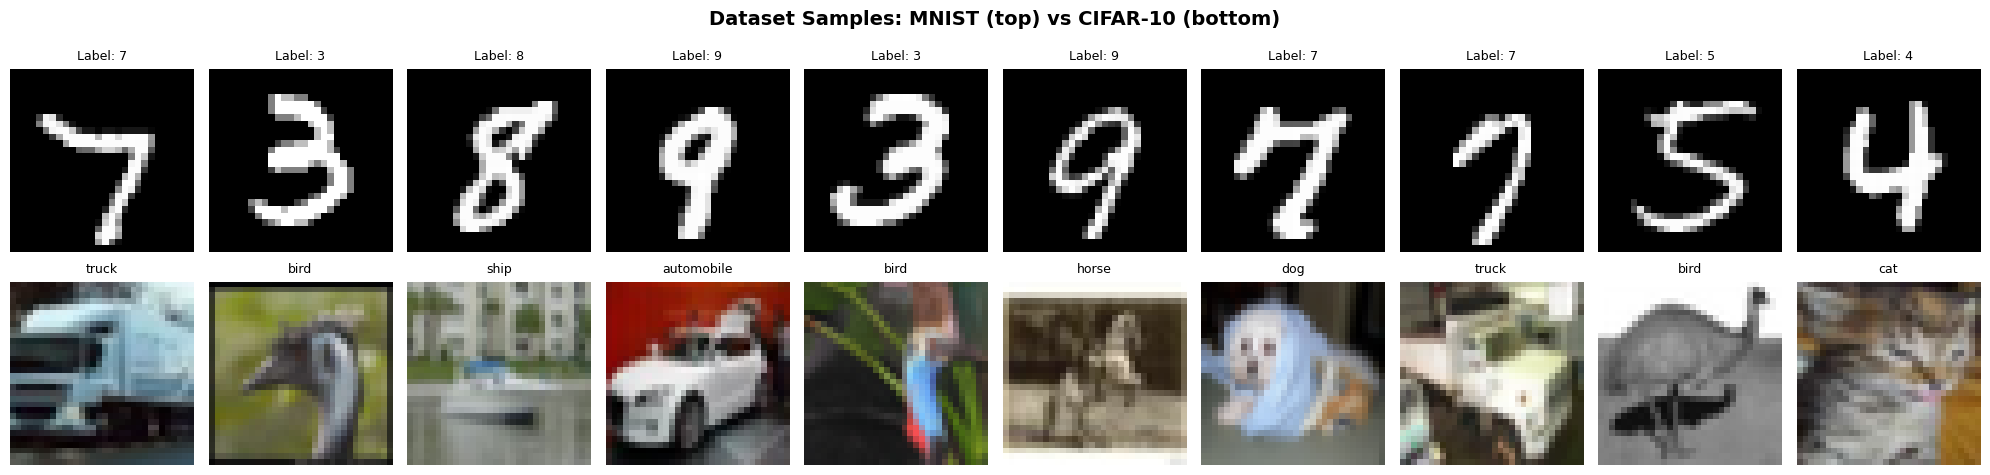

In [ ]:
# ============================================================
# PROBLEM 2: Dataset Exploration
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist, cifar10
import random

# Set seed for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# STEP 1: Load both datasets
# ============================================================
print("Loading datasets...")
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = cifar10.load_data()
print("Done!\n")

# ============================================================
# PART (a): Shape of training and test arrays
# ============================================================
print("=" * 45)
print("PART (a): SHAPES")
print("=" * 45)

print("MNIST:")
print(f"  Training images shape : {mnist_x_train.shape}")
print(f"  Training labels shape : {mnist_y_train.shape}")
print(f"  Test images shape     : {mnist_x_test.shape}")
print(f"  Test labels shape     : {mnist_y_test.shape}")

# Shape means: (number of images, height, width) for MNIST
# and (number of images, height, width, color channels) for CIFAR-10

print("\nCIFAR-10:")
print(f"  Training images shape : {cifar_x_train.shape}")
print(f"  Training labels shape : {cifar_y_train.shape}")
print(f"  Test images shape     : {cifar_x_test.shape}")
print(f"  Test labels shape     : {cifar_y_test.shape}")

# ============================================================
# PART (b): Data type and pixel value range
# ============================================================
print("\n" + "=" * 45)
print("PART (b): DATA TYPE AND PIXEL VALUE RANGE")
print("=" * 45)

print("MNIST:")
print(f"  Data type  : {mnist_x_train.dtype}")
print(f"  Min value  : {mnist_x_train.min()}")
print(f"  Max value  : {mnist_x_train.max()}")

print("\nCIFAR-10:")
print(f"  Data type  : {cifar_x_train.dtype}")
print(f"  Min value  : {cifar_x_train.min()}")
print(f"  Max value  : {cifar_x_train.max()}")

# NOTE: Both datasets have pixel values from 0 to 255 (uint8).
# This is raw, unprocessed data.
# When we train a neural network, we will NORMALIZE these values
# to a 0.0 to 1.0 range by dividing by 255.
# Why? Because small numbers (0-1) are easier for the network to learn from.

# ============================================================
# PART (c): Samples per class in MNIST — Is it balanced?
# ============================================================
print("\n" + "=" * 45)
print("PART (c): MNIST SAMPLES PER CLASS")
print("=" * 45)

# CIFAR-10 class names (in order 0 to 9)
mnist_class_names = ['0','1','2','3','4','5','6','7','8','9']

print("Class | Name | Count")
print("-" * 30)

counts = []
for i in range(10):
    count = np.sum(mnist_y_train == i)   # count how many images belong to class i
    counts.append(count)
    print(f"  {i}   |  {mnist_class_names[i]}   | {count}")

print("-" * 30)
print(f"Total samples: {sum(counts)}")
print(f"Min count: {min(counts)}")
print(f"Max count: {max(counts)}")

# Check if balanced
difference = max(counts) - min(counts)
if difference < 1000:
    print("\nBalanced? YES ✅")
    print(f"  Difference between most and least frequent class = {difference}")
    print("  All classes have roughly the same number of samples.")
else:
    print("\nBalanced? NO ❌")
    print(f"  Difference between most and least frequent class = {difference}")

# ============================================================
# STEP 2: Create 2x10 Grid Figure
# ============================================================
print("\n" + "=" * 45)
print("Creating 2x10 Grid Figure...")
print("=" * 45)

# CIFAR-10 class names (in order 0 to 9)
cifar_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Pick 10 random indexes for MNIST
mnist_random_indexes = np.random.choice(len(mnist_x_train), 10, replace=False)

# Pick 10 random indexes for CIFAR-10
cifar_random_indexes = np.random.choice(len(cifar_x_train), 10, replace=False)

# Create a big figure with 2 rows and 10 columns
fig, axes = plt.subplots(2, 10, figsize=(20, 5))

# --- TOP ROW: MNIST images ---
for col in range(10):
    idx = mnist_random_indexes[col]
    image = mnist_x_train[idx]          # get the image
    label = mnist_y_train[idx]          # get the label (a number 0-9)

    axes[0, col].imshow(image, cmap='gray')   # show in grayscale
    axes[0, col].set_title(f"Label: {label}", fontsize=9)
    axes[0, col].axis('off')                  # hide the x and y axis

# --- BOTTOM ROW: CIFAR-10 images ---
for col in range(10):
    idx = cifar_random_indexes[col]
    image = cifar_x_train[idx]                        # get the image
    label = cifar_y_train[idx][0]                     # get the label (a number 0-9)
    class_name = cifar_class_names[label]             # convert number to name

    axes[1, col].imshow(image)                        # show in color (no cmap needed)
    axes[1, col].set_title(f"{class_name}", fontsize=9)
    axes[1, col].axis('off')

# Add a title for each row on the left side
axes[0, 0].set_ylabel("MNIST", fontsize=13, fontweight='bold', rotation=0,
                        labelpad=50, va='center')
axes[1, 0].set_ylabel("CIFAR-10", fontsize=13, fontweight='bold', rotation=0,
                        labelpad=50, va='center')

# Overall title
fig.suptitle("Dataset Samples: MNIST (top) vs CIFAR-10 (bottom)",
             fontsize=14, fontweight='bold')

plt.tight_layout()

# Save the figure
plt.savefig("dataset_samples.png", dpi=150, bbox_inches='tight')
print("Figure saved as: dataset_samples.png ✅")

plt.show()

In [ ]:
# ============================================================
# PROBLEM 3: Preprocessing Pipeline
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist, cifar10

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# STEP 1: Load both datasets
# ============================================================
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = cifar10.load_data()

print("Datasets loaded!\n")

# ============================================================
# THE PREPROCESSING FUNCTION
# ============================================================

def preprocess(images, labels, dataset_name="Dataset"):
    """
    Takes raw images and labels and makes them ready for a CNN.

    Steps:
      (a) Normalize pixel values from 0-255 to 0.0-1.0
      (b) Reshape MNIST images to add channel dimension (only for MNIST)
      (c) One-hot encode the labels
    """

    print("=" * 50)
    print(f"PREPROCESSING: {dataset_name}")
    print("=" * 50)

    # ----------------------------------------------------------
    # PART (a): Normalize pixel values to [0.0, 1.0]
    # ----------------------------------------------------------
    print("\n--- PART (a): NORMALIZATION ---")
    print(f"BEFORE → dtype: {images.dtype}, min: {images.min()}, max: {images.max()}")
    print(f"BEFORE → sample pixel values: {images[0].flatten()[:5]}")
    # Sample shows first 5 pixel values of the first image

    # Divide by 255.0 (float, not integer!) to get values between 0.0 and 1.0
    # Also convert to float32 — this is the standard dtype for neural networks
    images = images.astype('float32') / 255.0

    # WHY float32?
    # Neural networks use float32 for calculations.
    # uint8 only stores whole numbers (0-255), can't store decimals like 0.502.
    # float32 stores decimals and is memory-efficient compared to float64.

    # WHY 255.0 and not 255?
    # If you divide by 255 (integer), Python might do integer division
    # and give wrong results. 255.0 forces decimal (float) division.

    print(f"\nAFTER  → dtype: {images.dtype}, min: {images.min():.1f}, max: {images.max():.1f}")
    print(f"AFTER  → sample pixel values: {images[0].flatten()[:5]}")

    # ----------------------------------------------------------
    # PART (b): Reshape — Add channel dimension (MNIST only)
    # ----------------------------------------------------------
    print("\n--- PART (b): RESHAPE (channel dimension) ---")
    print(f"BEFORE → shape: {images.shape}")

    if images.ndim == 3:
        # This means shape is (N, 28, 28) → MNIST (no channel)
        # We need to add a channel dimension → (N, 28, 28, 1)
        # CNNs expect: (number of images, height, width, color channels)
        # MNIST is grayscale so channel = 1
        # CIFAR-10 is already (N, 32, 32, 3) so we skip this step for it
        images = images.reshape(images.shape[0], images.shape[1], images.shape[2], 1)
        print(f"MNIST detected → Added channel dimension!")
    else:
        print(f"CIFAR-10 detected → Already has channel dimension, no reshape needed!")

    print(f"AFTER  → shape: {images.shape}")

    # ----------------------------------------------------------
    # PART (c): One-hot encode the labels
    # ----------------------------------------------------------
    print("\n--- PART (c): ONE-HOT ENCODING ---")

    # Flatten labels in case they are shape (N, 1) like CIFAR-10
    labels = labels.flatten()

    print(f"BEFORE → shape: {labels.shape}, dtype: {labels.dtype}")
    print(f"BEFORE → sample labels (first 5): {labels[:5]}")
    # e.g., [3, 7, 1, 0, 4]

    # One-hot encoding means turning a number into a vector of 0s and 1s
    # Example:
    #   Label = 3  →  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
    #   Label = 7  →  [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
    # Why? Because the CNN outputs 10 probabilities (one per class),
    # and we need the label in the same format to compare and calculate loss.

    num_classes = 10
    labels_onehot = np.zeros((labels.shape[0], num_classes), dtype='float32')
    # Creates a big grid of zeros: shape = (number of samples, 10)

    for i in range(labels.shape[0]):
        labels_onehot[i, labels[i]] = 1.0
        # For each sample, put a 1 in the correct class position

    print(f"\nAFTER  → shape: {labels_onehot.shape}, dtype: {labels_onehot.dtype}")
    print(f"AFTER  → sample labels (first 5):")
    for i in range(5):
        print(f"  Label {labels[i]} → {labels_onehot[i]}")

    print(f"\n{dataset_name} preprocessing DONE ✅")
    return images, labels_onehot


# ============================================================
# STEP 2: Run the function on both datasets
# ============================================================

# Process MNIST
mnist_x_train_p, mnist_y_train_p = preprocess(mnist_x_train, mnist_y_train, "MNIST Training")
mnist_x_test_p,  mnist_y_test_p  = preprocess(mnist_x_test,  mnist_y_test,  "MNIST Test")

print("\n")

# Process CIFAR-10
cifar_x_train_p, cifar_y_train_p = preprocess(cifar_x_train, cifar_y_train, "CIFAR-10 Training")
cifar_x_test_p,  cifar_y_test_p  = preprocess(cifar_x_test,  cifar_y_test,  "CIFAR-10 Test")


# ============================================================
# STEP 3: Final Summary
# ============================================================
print("\n")
print("=" * 50)
print("FINAL SUMMARY — ALL SHAPES AFTER PREPROCESSING")
print("=" * 50)
print(f"MNIST   Train images : {mnist_x_train_p.shape}  | dtype: {mnist_x_train_p.dtype}")
print(f"MNIST   Train labels : {mnist_y_train_p.shape}     | dtype: {mnist_y_train_p.dtype}")
print(f"MNIST   Test  images : {mnist_x_test_p.shape}   | dtype: {mnist_x_test_p.dtype}")
print(f"MNIST   Test  labels : {mnist_y_test_p.shape}      | dtype: {mnist_y_test_p.dtype}")
print()
print(f"CIFAR   Train images : {cifar_x_train_p.shape}  | dtype: {cifar_x_train_p.dtype}")
print(f"CIFAR   Train labels : {cifar_y_train_p.shape}     | dtype: {cifar_y_train_p.dtype}")
print(f"CIFAR   Test  images : {cifar_x_test_p.shape}   | dtype: {cifar_x_test_p.dtype}")
print(f"CIFAR   Test  labels : {cifar_y_test_p.shape}      | dtype: {cifar_y_test_p.dtype}")
print("=" * 50)

Datasets loaded!

PREPROCESSING: MNIST Training

--- PART (a): NORMALIZATION ---
BEFORE → dtype: uint8, min: 0, max: 255
BEFORE → sample pixel values: [0 0 0 0 0]

AFTER  → dtype: float32, min: 0.0, max: 1.0
AFTER  → sample pixel values: [0. 0. 0. 0. 0.]

--- PART (b): RESHAPE (channel dimension) ---
BEFORE → shape: (60000, 28, 28)
MNIST detected → Added channel dimension!
AFTER  → shape: (60000, 28, 28, 1)

--- PART (c): ONE-HOT ENCODING ---
BEFORE → shape: (60000,), dtype: uint8
BEFORE → sample labels (first 5): [5 0 4 1 9]

AFTER  → shape: (60000, 10), dtype: float32
AFTER  → sample labels (first 5):
  Label 5 → [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  Label 0 → [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Label 4 → [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
  Label 1 → [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
  Label 9 → [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]

MNIST Training preprocessing DONE ✅
PREPROCESSING: MNIST Test

--- PART (a): NORMALIZATION ---
BEFORE → dtype: uint8, min: 0, max: 255
BEFORE → sample pixel values: [0 

CIFAR-10 loaded and normalized!
Shape: (50000, 32, 32, 3)

Augmentation pipeline built!
  (a) Horizontal Flip  → probability 0.5
  (b) Random Rotation  → ±10 degrees
  (c) Random Zoom      → up to 10%

Selected 5 random images:
  Image 1: index 33553 → class 'horse'
  Image 2: index 9427 → class 'ship'
  Image 3: index 199 → class 'airplane'
  Image 4: index 12447 → class 'frog'
  Image 5: index 39489 → class 'automobile'

Figure saved as: augmentation_demo.png ✅


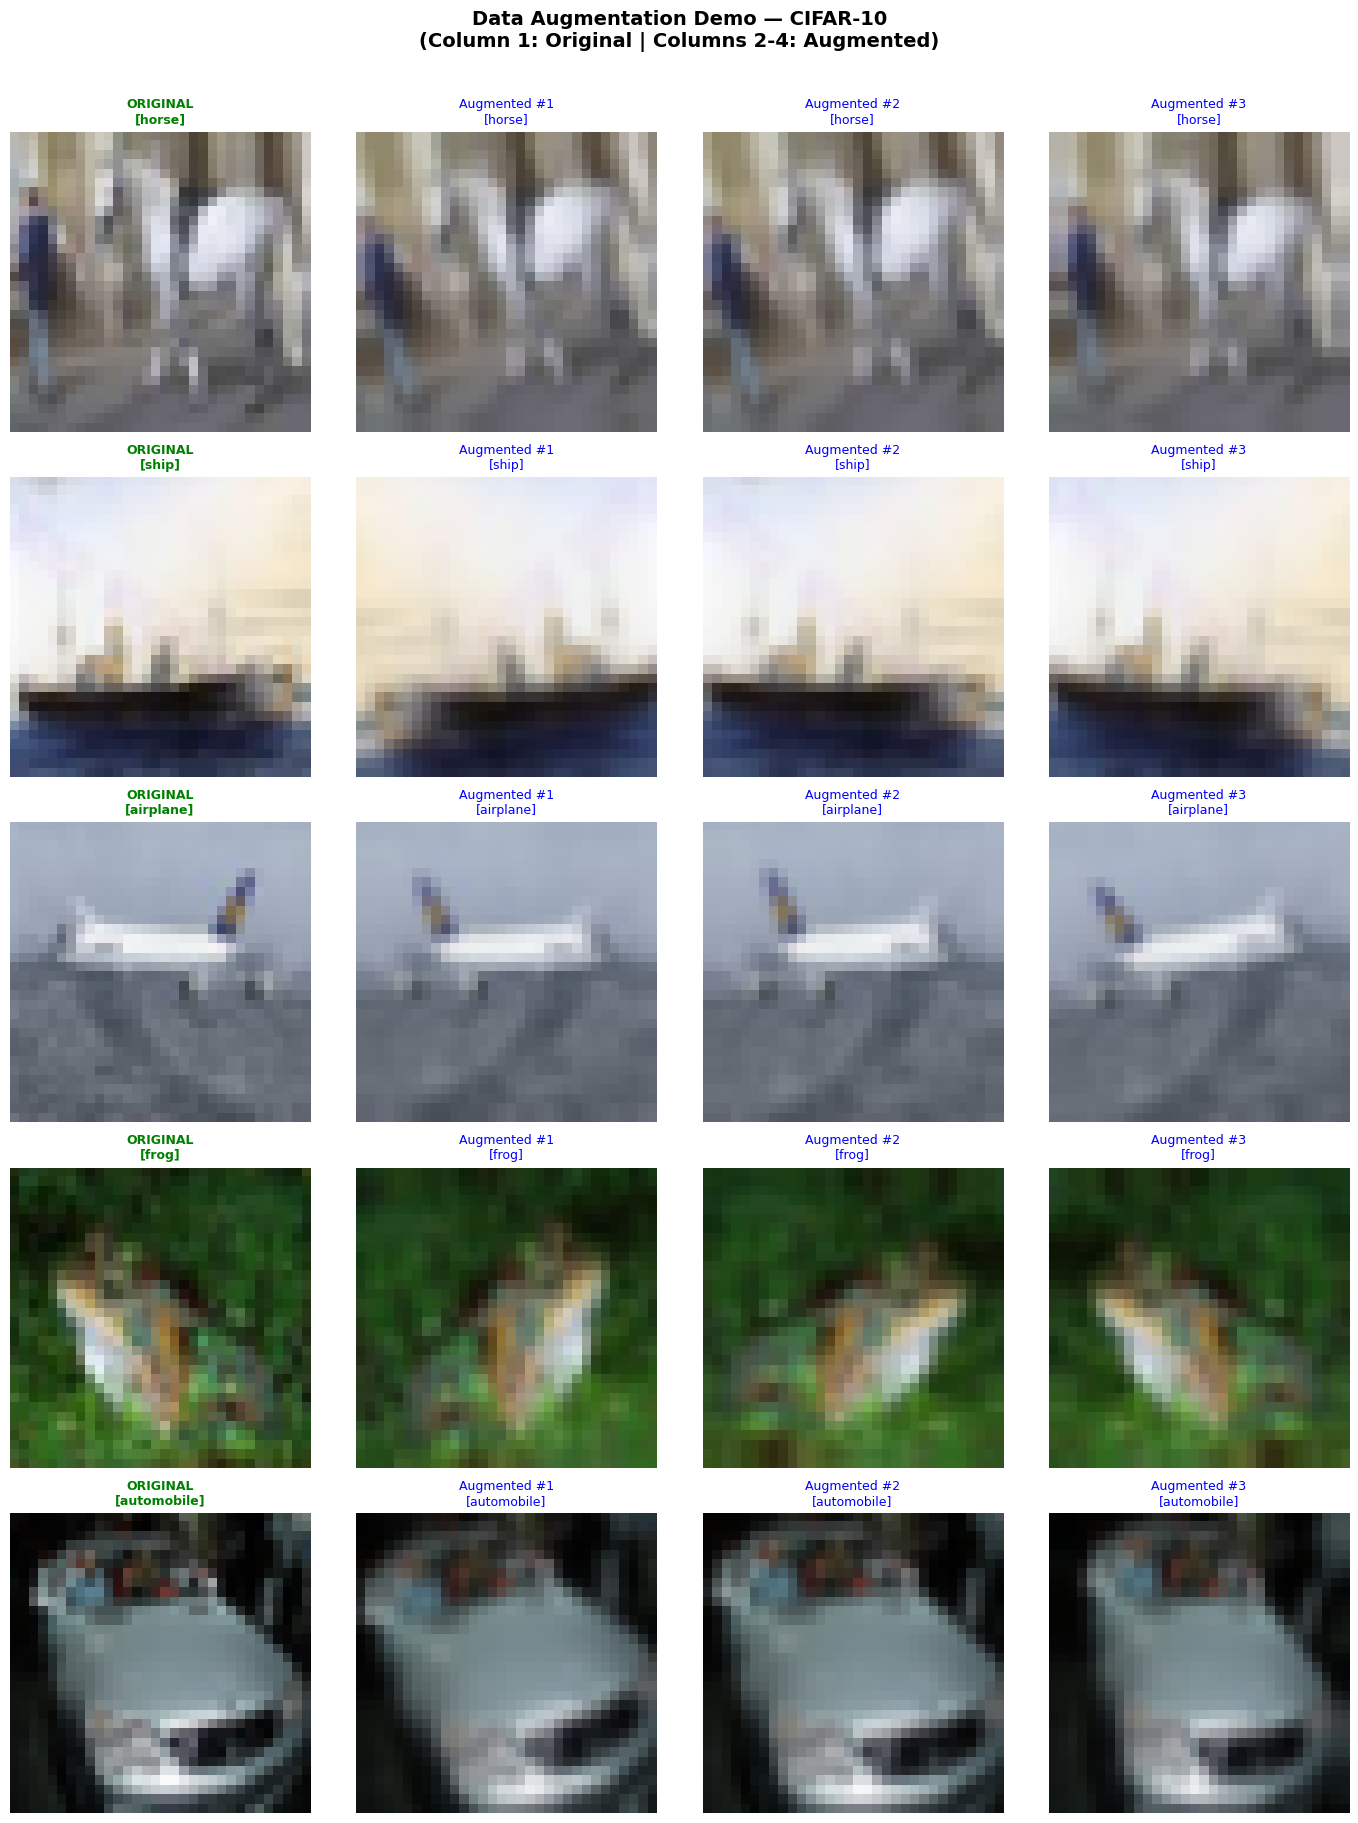


WHY AUGMENTATION IS ONLY FOR TRAINING — NOT VALIDATION/TEST

JUSTIFICATION:

1. PURPOSE OF AUGMENTATION:
   Augmentation artificially increases the variety of training data.
   It teaches the model to recognize objects even when they are
   flipped, rotated, or zoomed — making the model more ROBUST.

2. WHY NOT ON VALIDATION OR TEST SET:
   The validation and test sets are used to MEASURE how well the
   model performs on real-world, unseen data.

   If we augment these sets:
   → The images no longer look like real-world inputs.
   → Our accuracy score becomes unreliable and misleading.
   → We can't trust whether the model is actually learning or not.

   Think of it like an EXAM:
   → Training = practice at home (you can vary the questions)
   → Test/Validation = the real exam (must be consistent & fair)
   Changing the exam questions each time makes results meaningless.

3. CONSISTENCY MATTERS:
   Test images must always be the SAME so we can compare results
   across different mo

In [ ]:
# ============================================================
# PROBLEM 4: Data Augmentation Pipeline
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# STEP 1: Load and Normalize CIFAR-10
# ============================================================
(cifar_x_train, cifar_y_train), (_, _) = cifar10.load_data()

# Normalize to [0.0, 1.0]
cifar_x_train = cifar_x_train.astype('float32') / 255.0

cifar_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("CIFAR-10 loaded and normalized!")
print(f"Shape: {cifar_x_train.shape}\n")

# ============================================================
# STEP 2: Build the Augmentation Pipeline
# ============================================================

# We use Keras built-in augmentation layers (no GPU needed)
# Each layer applies a random transformation every time it's called

augmentation_pipeline = tf.keras.Sequential([

    # (a) Horizontal Flip with probability 0.5
    # Randomly flips the image left-right, 50% of the time
    # WHY it's safe for CIFAR-10: A flipped airplane is still an airplane,
    # a flipped car is still a car. Labels don't change.
    # WHY NOT for MNIST: A flipped '6' looks like '9' → label would be WRONG!
    layers.RandomFlip("horizontal"),

    # (b) Random Rotation in range ±10 degrees
    # Rotates the image by a random angle between -10 and +10 degrees
    # factor=0.1 means 10% of 360 degrees = ±36 degrees MAX
    # But we want ±10 degrees, so factor = 10/360 ≈ 0.028
    layers.RandomRotation(factor=0.028),

    # (c) Random Zoom of up to 10%
    # Zooms in or out randomly by up to 10%
    # height_factor=0.1 means zoom by up to 10%
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),

], name="augmentation_pipeline")

print("Augmentation pipeline built!")
print("  (a) Horizontal Flip  → probability 0.5")
print("  (b) Random Rotation  → ±10 degrees")
print("  (c) Random Zoom      → up to 10%\n")

# ============================================================
# STEP 3: Pick 5 random CIFAR-10 images
# ============================================================
random_indexes = np.random.choice(len(cifar_x_train), 5, replace=False)

selected_images = cifar_x_train[random_indexes]
selected_labels = cifar_y_train[random_indexes].flatten()

print("Selected 5 random images:")
for i, idx in enumerate(random_indexes):
    print(f"  Image {i+1}: index {idx} → class '{cifar_class_names[selected_labels[i]]}'")

# ============================================================
# STEP 4: Apply augmentation and create 5x4 grid
# ============================================================

# The grid has:
# - 5 rows    → one row per image
# - 4 columns → col 0 = original, col 1/2/3 = 3 augmented versions

fig, axes = plt.subplots(5, 4, figsize=(14, 18))

fig.suptitle("Data Augmentation Demo — CIFAR-10\n(Column 1: Original | Columns 2-4: Augmented)",
             fontsize=14, fontweight='bold', y=1.01)

for row in range(5):

    original_image = selected_images[row]         # shape: (32, 32, 3)
    label_name     = cifar_class_names[selected_labels[row]]

    # --- COLUMN 0: Original image ---
    axes[row, 0].imshow(original_image)
    axes[row, 0].set_title(f"ORIGINAL\n[{label_name}]", fontsize=9, fontweight='bold', color='green')
    axes[row, 0].axis('off')

    # --- COLUMNS 1, 2, 3: Three different augmented versions ---
    for col in range(1, 4):

        # Add batch dimension: (32, 32, 3) → (1, 32, 32, 3)
        # Keras augmentation layers expect a BATCH of images, not a single image
        image_batch = tf.expand_dims(original_image, axis=0)

        # Apply augmentation — each call gives a DIFFERENT random result
        augmented_batch = augmentation_pipeline(image_batch, training=True)
        # training=True is IMPORTANT — augmentation only runs when training=True
        # If training=False, the image passes through unchanged

        # Remove batch dimension: (1, 32, 32, 3) → (32, 32, 3)
        augmented_image = augmented_batch[0].numpy()

        # Clip values to [0, 1] just in case augmentation pushed values slightly out
        augmented_image = np.clip(augmented_image, 0.0, 1.0)

        axes[row, col].imshow(augmented_image)
        axes[row, col].set_title(f"Augmented #{col}\n[{label_name}]", fontsize=9, color='blue')
        axes[row, col].axis('off')

# Add row labels on the left side
for row in range(5):
    axes[row, 0].set_ylabel(f"Image {row+1}", fontsize=11,
                             fontweight='bold', rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig("augmentation_demo.png", dpi=150, bbox_inches='tight')
print("\nFigure saved as: augmentation_demo.png ✅")
plt.show()


# ============================================================
# STEP 5: Written Justification (also printed as output)
# ============================================================
print("\n" + "=" * 60)
print("WHY AUGMENTATION IS ONLY FOR TRAINING — NOT VALIDATION/TEST")
print("=" * 60)

justification = """
JUSTIFICATION:

1. PURPOSE OF AUGMENTATION:
   Augmentation artificially increases the variety of training data.
   It teaches the model to recognize objects even when they are
   flipped, rotated, or zoomed — making the model more ROBUST.

2. WHY NOT ON VALIDATION OR TEST SET:
   The validation and test sets are used to MEASURE how well the
   model performs on real-world, unseen data.

   If we augment these sets:
   → The images no longer look like real-world inputs.
   → Our accuracy score becomes unreliable and misleading.
   → We can't trust whether the model is actually learning or not.

   Think of it like an EXAM:
   → Training = practice at home (you can vary the questions)
   → Test/Validation = the real exam (must be consistent & fair)
   Changing the exam questions each time makes results meaningless.

3. CONSISTENCY MATTERS:
   Test images must always be the SAME so we can compare results
   across different models and training runs fairly.

4. LABEL PRESERVATION (which augmentations are safe for CIFAR-10):
   ✅ Horizontal Flip  → A flipped car/airplane still looks correct
   ✅ Rotation ±10°   → A slightly rotated dog is still a dog
   ✅ Zoom up to 10%  → A zoomed-in cat is still a cat

   ❌ Horizontal Flip on MNIST → '6' flipped looks like '9' (WRONG label!)
   ❌ Large rotation on digits → '9' rotated 180° looks like '6' (WRONG!)

   So augmentation must only use transformations that PRESERVE
   the true meaning/label of the image.
"""

print(justification)

Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)? Explain with reference to
both a greyscale image and an RGB image.
Ans. The shape (N, H, W, C) represents a batch of images where N = number of images, H = height in pixels, W = width in pixels, and C = number of channels. The channel dimension tells us how many types of information each pixel holds. For a greyscale image (like MNIST), C = 1 because each pixel only stores one value — its brightness (0 to 255). For an RGB image (like CIFAR-10), C = 3 because each pixel stores three values — Red, Green, and Blue — which combine to form any colour. This is why we reshaped MNIST from (N, 28, 28) to (N, 28, 28, 1) in preprocessing — to explicitly tell the CNN that there is 1 channel, since CNNs require the channel dimension to be present in order to apply their filters correctly.

Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images, what
data loading strategies would you use to avoid running out of memory? Name at least two techniques and
explain how each one helps.
Ans. When working with large images like 1024×1024 satellite images, loading the entire dataset into RAM at once would crash your system. The two main strategies to handle this are Data Generators and Mixed Precision Training. A Data Generator (like Keras's ImageDataGenerator or tf.data.Dataset) loads images in small batches on-the-fly instead of all at once — so instead of loading 50,000 huge images into memory, you only load 32 at a time, process them, and then discard them before loading the next batch. This keeps memory usage small and constant no matter how large the dataset is. The second technique is Image Patching, where instead of feeding the full 1024×1024 image into the CNN, you cut it into smaller patches (e.g., 128×128 or 256×256) and train on those patches — this drastically reduces the size of each input and allows the model to still learn features without needing massive memory. Together, these two techniques allow you to train on very large images even on a machine with limited RAM or no GPU.

Q3. Suppose a student applies normalisation to the test set using the mean and standard deviation
computed from the test set itself. What is wrong with this approach?
Ans.this approach?7:29 PMThis is a form of data leakage. The test set is supposed to simulate completely unseen, real-world data — the model should never have any information from it during training or preprocessing. When you compute the mean and standard deviation from the test set itself and use those values to normalise it, you are allowing information from the test set to influence the preprocessing, which makes the evaluation unfair and unreliable. The correct approach is to compute the mean and standard deviation only from the training set, and then apply those exact same values to normalise both the validation and test sets. This way, the test set is treated as if it truly came from the outside world — the model and all preprocessing steps remain completely blind to it, and the accuracy score you get is a honest reflection of real-world performance.

TASK 2


In [ ]:
# ============================================================
# PROBLEM 1: Manual 2D Convolution (NumPy only)
# ============================================================

import numpy as np

np.random.seed(42)

# ============================================================
# STEP 1: Define the conv2d function
# ============================================================

def conv2d(image, kernel, stride=1, padding=0):
    """
    Performs 2D convolution manually using only NumPy.

    Parameters:
      image   : 2D numpy array (the input image)
      kernel  : 2D numpy array (the filter)
      stride  : how many pixels to move the kernel each step
      padding : how many zeros to add around the image border

    Returns:
      feature_map : 2D numpy array (the output)
    """

    # ----------------------------------------------------------
    # PART (a): Get sizes of image and kernel
    # ----------------------------------------------------------
    image_h, image_w   = image.shape     # image height and width
    kernel_h, kernel_w = kernel.shape    # kernel height and width

    # ----------------------------------------------------------
    # PART (b): Apply zero-padding if needed
    # ----------------------------------------------------------
    if padding > 0:
        # np.pad adds zeros around the image border
        # (padding, padding) means add 'padding' zeros on EACH side
        image = np.pad(image,
                       pad_width=((padding, padding), (padding, padding)),
                       mode='constant',
                       constant_values=0)
        print(f"  Padding applied: {padding} zero(s) added on each side")
        print(f"  Image shape after padding: {image.shape}")

    # ----------------------------------------------------------
    # Calculate output size using the formula:
    # output_size = (input_size - kernel_size + 2*padding) / stride + 1
    # ----------------------------------------------------------
    output_h = int((image_h - kernel_h + 2 * padding) / stride) + 1
    output_w = int((image_w - kernel_w + 2 * padding) / stride) + 1

    print(f"\n  Output size formula:")
    print(f"  output_h = ({image_h} - {kernel_h} + 2*{padding}) / {stride} + 1 = {output_h}")
    print(f"  output_w = ({image_w} - {kernel_w} + 2*{padding}) / {stride} + 1 = {output_w}")

    # Create an empty output array filled with zeros
    feature_map = np.zeros((output_h, output_w))

    # ----------------------------------------------------------
    # PART (c): Slide the kernel across the image
    # ----------------------------------------------------------
    # We use nested for-loops:
    # - Outer loop moves DOWN  the image (rows)
    # - Inner loop moves ACROSS the image (columns)

    for row in range(output_h):
        for col in range(output_w):

            # Calculate where the kernel window starts in the image
            row_start = row * stride
            row_end   = row_start + kernel_h

            col_start = col * stride
            col_end   = col_start + kernel_w

            # Extract the patch (small piece of image under the kernel)
            patch = image[row_start:row_end, col_start:col_end]

            # Element-wise multiply patch by kernel, then sum all values
            # This is the core convolution operation
            feature_map[row, col] = np.sum(patch * kernel)

            # Example of what happens:
            # patch = [[3,1,0],    kernel = [[-1,0,1],
            #          [1,5,3],              [-2,0,2],
            #          [0,2,6]]              [-1,0,1]]
            #
            # multiply element by element:
            # [[-3,0,0], [-2,0,6], [0,0,6]]
            # sum all = 7  → this goes into feature_map[row, col]

    return feature_map


# ============================================================
# STEP 2: Define the test image and Sobel-X kernel
# ============================================================

# 5×5 test image (given in the problem)
image = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
], dtype=float)

# Sobel-X kernel (detects vertical edges / horizontal changes)
# Negative on left → positive on right
# This highlights places where brightness changes left-to-right
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=float)

print("=" * 50)
print("INPUT IMAGE (5×5):")
print("=" * 50)
print(image)

print("\nSOBEL-X KERNEL (3×3):")
print(kernel)

# ============================================================
# STEP 3: Run the convolution
# ============================================================
print("\n" + "=" * 50)
print("RUNNING CONVOLUTION (stride=1, padding=0)")
print("=" * 50)

feature_map = conv2d(image, kernel, stride=1, padding=0)

# ============================================================
# STEP 4: Print the output
# ============================================================
print("\n" + "=" * 50)
print("OUTPUT FEATURE MAP:")
print("=" * 50)
print(feature_map)

print("\n" + "=" * 50)
print("SHAPE VERIFICATION")
print("=" * 50)
print(f"Input image shape  : {image.shape}  → (5 × 5)")
print(f"Kernel shape       : {kernel.shape}  → (3 × 3)")
print(f"Stride             : 1")
print(f"Padding            : 0")
print(f"\nFormula: output = (input - kernel + 2×padding) / stride + 1")
print(f"       = (5 - 3 + 2×0) / 1 + 1")
print(f"       = (2) / 1 + 1")
print(f"       = 3 + 0 = 3")
print(f"\nExpected output shape : (3 × 3)")
print(f"Actual output shape   : {feature_map.shape}")

if feature_map.shape == (3, 3):
    print("\nShape verification PASSED ✅")
else:
    print("\nShape verification FAILED ❌")

# ============================================================
# STEP 5: What does the Sobel-X output tell us?
# ============================================================
print("\n" + "=" * 50)
print("WHAT DOES THE OUTPUT MEAN?")
print("=" * 50)
print("""
The Sobel-X kernel detects VERTICAL EDGES in the image.
It looks for places where pixel brightness changes LEFT to RIGHT.

  Positive values → brightness increases left to right (light edge)
  Negative values → brightness decreases left to right (dark edge)
  Near zero       → no strong horizontal change (flat region)

The output feature map highlights WHERE these edges are in the image.
This is exactly what the first layers of a CNN do automatically —
they learn kernels (filters) that detect edges, corners, and patterns.
""")

INPUT IMAGE (5×5):
[[3. 1. 0. 2. 4.]
 [1. 5. 3. 2. 1.]
 [0. 2. 6. 4. 3.]
 [2. 3. 1. 5. 2.]
 [1. 0. 2. 3. 4.]]

SOBEL-X KERNEL (3×3):
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

RUNNING CONVOLUTION (stride=1, padding=0)

  Output size formula:
  output_h = (5 - 3 + 2*0) / 1 + 1 = 3
  output_w = (5 - 3 + 2*0) / 1 + 1 = 3

OUTPUT FEATURE MAP:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

SHAPE VERIFICATION
Input image shape  : (5, 5)  → (5 × 5)
Kernel shape       : (3, 3)  → (3 × 3)
Stride             : 1
Padding            : 0

Formula: output = (input - kernel + 2×padding) / stride + 1
       = (5 - 3 + 2×0) / 1 + 1
       = (2) / 1 + 1
       = 3 + 0 = 3

Expected output shape : (3 × 3)
Actual output shape   : (3, 3)

Shape verification PASSED ✅

WHAT DOES THE OUTPUT MEAN?

The Sobel-X kernel detects VERTICAL EDGES in the image.
It looks for places where pixel brightness changes LEFT to RIGHT.

  Positive values → brightness increases left to right (light edge)
  Negative values → 

Problem 2
### Convolution Output Size Formula

$$
\text{Output Size} = \left\lfloor \frac{\text{Input} - \text{Kernel} + 2 \times \text{Padding}}{\text{Stride}} \right\rfloor + 1
$$

---

### (a) Input: 28×28, Kernel: 5×5, Padding: 0, Stride: 1

$$
= \left\lfloor \frac{28 - 5 + 2 \times 0}{1} \right\rfloor + 1
= \left\lfloor \frac{23}{1} \right\rfloor + 1
= 23 + 1 = 24
$$

✅ Output: **24 × 24**

---

### (b) Input: 28×28, Kernel: 3×3, Padding: 1, Stride: 1

$$
= \left\lfloor \frac{28 - 3 + 2 \times 1}{1} \right\rfloor + 1
= \left\lfloor \frac{27}{1} \right\rfloor + 1
= 27 + 1 = 28
$$

✅ Output: **28 × 28**

---

### (c) Input: 32×32, Kernel: 3×3, Padding: 0, Stride: 2

$$
= \left\lfloor \frac{32 - 3 + 2 \times 0}{2} \right\rfloor + 1
= \left\lfloor \frac{29}{2} \right\rfloor + 1
= \left\lfloor 14.5 \right\rfloor + 1
= 14 + 1 = 15
$$

✅ Output: **15 × 15**

---

### (d) Two Consecutive Conv2D Layers

**Layer 1:** K=3, P=1, S=1

$$
= \left\lfloor \frac{32 - 3 + 2 \times 1}{1} \right\rfloor + 1
= 32
$$

**Layer 2:** K=3, P=0, S=1

$$
= \left\lfloor \frac{32 - 3 + 2 \times 0}{1} \right\rfloor + 1
= 30
$$

✅ Final Output: **30 × 30**

Problem 3

In [ ]:
# ============================================================
# LeNet-5 Implementation
# ============================================================

# Step 1: Install TensorFlow (already available in Colab)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ============================================================
# BUILD THE MODEL
# ============================================================

model = keras.Sequential([

    # Layer 1: Conv2D — 6 filters, 5x5, no padding, input is 28x28 grayscale
    layers.Conv2D(filters=6, kernel_size=(5, 5), padding='valid',
                  activation='tanh', input_shape=(28, 28, 1)),

    # Layer 2: Average Pooling — 2x2 window, stride 2
    layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    # Layer 3: Conv2D — 16 filters, 5x5, no padding
    layers.Conv2D(filters=16, kernel_size=(5, 5), padding='valid',
                  activation='tanh'),

    # Layer 4: Average Pooling — 2x2 window, stride 2
    layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    # Layer 5: Flatten — converts 2D feature maps into 1D
    layers.Flatten(),

    # Layer 6: Fully connected — 120 neurons
    layers.Dense(units=120, activation='tanh'),

    # Layer 7: Fully connected — 84 neurons
    layers.Dense(units=84, activation='tanh'),

    # Layer 8: Output layer — 10 classes (digits 0-9)
    layers.Dense(units=10, activation='softmax')
])

# ============================================================
# PART (a): Print model summary — check total params = 44,426
# ============================================================

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# Problem 4: Custom CNN for CIFAR-10
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ============================================================
# BUILD THE MODEL
# ============================================================

model = keras.Sequential([

    # ----- BLOCK 1 -----
    # Input: 32x32x3 (colour image)
    layers.Conv2D(filters=32, kernel_size=(3,3), padding='same',
                  input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    # Output: 16x16x32

    # ----- BLOCK 2 -----
    layers.Conv2D(filters=64, kernel_size=(3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    # Output: 8x8x64

    # ----- BLOCK 3 -----
    layers.Conv2D(filters=128, kernel_size=(3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    # Output: 4x4x128

    # ----- CLASSIFICATION HEAD -----
    # GlobalAveragePooling squashes 4x4x128 → just 128 numbers
    layers.GlobalAveragePooling2D(),

    # Fully connected layer
    layers.Dense(units=256, activation='relu'),

    # Dropout to prevent overfitting (randomly turn off 40% of neurons)
    layers.Dropout(rate=0.4),

    # Final output: 10 classes (airplane, car, bird, etc.)
    layers.Dense(units=10, activation='softmax')
])

# ============================================================
# PRINT SUMMARY — check parameter count is between 200K–2M
# ============================================================

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the
same input with the same number of filters. Which uses fewer parameters? Show numerical proof and
explain any other advantages of the smaller kernel approach.
Ans. Two stacked 3×3 convolution layers use fewer parameters than one 5×5 layer for the same number of filters.
A single 5×5 layer has 25C² parameters (since 5×5 = 25), while two 3×3 layers together have 2 × 9C² = 18C² parameters.
So, 18C² < 25C², meaning the stacked 3×3 layers are more parameter efficient.
Even though both cover the same receptive field (5×5), the smaller kernels reduce computation.
Also, using two layers adds an extra activation function, helping the network learn more complex patterns.

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or
after activation), and why? Mention at least two empirical benefits it provides during training.
Ans. Batch Normalisation is used to stabilise and speed up training by keeping the inputs to each layer well-scaled.
It is usually placed after the convolution layer and before the activation function, so that the activation receives normalised data.
This helps maintain a consistent distribution of values as training progresses.
One benefit is that it allows using higher learning rates without the model diverging.
Another benefit is that it reduces overfitting slightly by adding a regularising effect.


Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head. What does this layer do
geometrically? What would happen to the parameter count and spatial information if you replaced it with
Flatten?
Ans.GlobalAveragePooling takes each feature map and averages all its values into a single number, so geometrically it converts each channel into one value and removes the spatial dimensions.
This means the output becomes a vector of size equal to the number of channels.
If you replace it with Flatten, all spatial values are kept and turned into a long vector instead.
This will greatly increase the number of parameters in the Dense layer.
Also, Flatten keeps spatial details, while GlobalAveragePooling loses exact location information but makes the model simpler and less prone to overfitting.

TASK 3


In [ ]:
# ============================================================
# Problem 1 - Train LeNet-5 on MNIST using SGD
# ============================================================

# Step 1: Import all the libraries we need
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# ============================================================
# Step 2: Load the MNIST dataset
# ============================================================
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Resize images from 28x28 to 32x32 (LeNet-5 expects 32x32)
x_train = tf.image.resize(x_train[..., np.newaxis], [32, 32]).numpy()
x_test  = tf.image.resize(x_test[..., np.newaxis],  [32, 32]).numpy()

# Normalize pixel values from 0-255 to 0-1 (makes training easier)
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# Convert labels to one-hot encoding
# Example: label 3 becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

print("Training data shape  :", x_train.shape)
print("Test data shape      :", x_test.shape)

# ============================================================
# Step 3: Build the LeNet-5 Model
# ============================================================
def build_lenet5():
    model = models.Sequential([

        # --- Block 1 ---
        # 6 filters of size 5x5, then shrink with average pooling
        layers.Conv2D(6, kernel_size=5, activation='tanh', input_shape=(32, 32, 1)),
        layers.AveragePooling2D(pool_size=2, strides=2),

        # --- Block 2 ---
        # 16 filters of size 5x5, then shrink again
        layers.Conv2D(16, kernel_size=5, activation='tanh'),
        layers.AveragePooling2D(pool_size=2, strides=2),

        # --- Flatten ---
        # Convert 2D feature maps into a 1D list of numbers
        layers.Flatten(),

        # --- Fully Connected Layers ---
        layers.Dense(120, activation='tanh'),
        layers.Dense(84,  activation='tanh'),

        # --- Output Layer ---
        # 10 neurons = 10 digit classes (0 to 9)
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_lenet5()
model.summary()

# ============================================================
# Step 4: Compile the model
# ============================================================
# SGD optimizer with learning rate 0.01
# categorical_crossentropy because we have 10 classes
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# Step 5: Train the model
# ============================================================
# 15 epochs, batch size 64, 10% of training data used for validation
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,   # 10% of training data becomes validation
    verbose=1               # Show progress bar
)

# ============================================================
# Step 6: Plot Training vs Validation Loss & Accuracy
# ============================================================

epochs_range = range(1, 16)   # Epoch numbers 1 to 15

# --- Find overfitting epoch ---
# Overfitting = val_loss starts going UP while train_loss goes DOWN
val_loss = history.history['val_loss']
overfit_epoch = None

for i in range(1, len(val_loss)):
    if val_loss[i] > val_loss[i - 1]:
        overfit_epoch = i + 1   # +1 because epochs start from 1
        break

if overfit_epoch:
    print(f"\n⚠️  Overfitting first detected at epoch: {overfit_epoch}")
else:
    print("\n✅ No clear overfitting detected in 15 epochs.")

# ============================================================
# Create the figure with 2 plots side by side
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LeNet-5 Training with SGD on MNIST', fontsize=14, fontweight='bold')

# ---------- Plot (a): Loss ----------
ax1.plot(epochs_range, history.history['loss'],     label='Training Loss',   color='blue',  linewidth=2)
ax1.plot(epochs_range, history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)

# Mark the overfitting epoch if found
if overfit_epoch:
    ax1.axvline(x=overfit_epoch, color='red', linestyle='--', linewidth=1.5,
                label=f'Overfit starts (Epoch {overfit_epoch})')

ax1.set_title('(a) Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# ---------- Plot (b): Accuracy ----------
ax2.plot(epochs_range, history.history['accuracy'],     label='Training Accuracy',   color='blue',  linewidth=2)
ax2.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)

# Mark the overfitting epoch on accuracy plot too
if overfit_epoch:
    ax2.axvline(x=overfit_epoch, color='red', linestyle='--', linewidth=1.5,
                label=f'Overfit starts (Epoch {overfit_epoch})')

ax2.set_title('(b) Training vs Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

# Save the plot
plt.savefig('lenet_sgd_curves.png', dpi=150)
plt.show()
print("\n✅ Plot saved as: lenet_sgd_curves.png")

# ============================================================
# Step 7: (d) Report Final Test Accuracy
# ============================================================
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("\n" + "="*40)
print("       FINAL RESULTS SUMMARY")
print("="*40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy*100:.2f}%")
if overfit_epoch:
    print(f"  Overfit Epoch : {overfit_epoch}")
else:
    print(f"  Overfitting   : Not detected")
print("="*40)

Training data shape  : (60000, 32, 32, 1)
Test data shape      : (10000, 32, 32, 1)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7864 - loss: 0.8374 - val_accuracy: 0.9150 - val_loss: 0.3347
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9019 - loss: 0.3480 - val_accuracy: 0.9342 - val_loss: 0.2453
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9198 - loss: 0.2776 - val_accuracy: 0.9430 - val_loss: 0.2025
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9312 - loss: 0.2352 - val_accuracy: 0.9547 - val_loss: 0.1736
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9404 - loss: 0.2044 - val_accuracy: 0.9603 - val_loss: 0.1523
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9467 - loss: 0.1808 - val_accuracy: 0.9628 - val_loss: 0.1361
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9523 - loss: 0.1620 - val_accuracy: 0.9665 - val_loss: 0.1234
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9564 - loss: 0.1468 - val_accuracy: 0.

In [ ]:
# ============================================================
# Problem 2 - Compare 3 Optimisers on LeNet-5
# ============================================================

# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# ============================================================
# Step 2: Load and Prepare MNIST Data
# (Same as Problem 1 - just rerun this)
# ============================================================
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Resize to 32x32 for LeNet-5
x_train = tf.image.resize(x_train[..., np.newaxis], [32, 32]).numpy()
x_test  = tf.image.resize(x_test[..., np.newaxis],  [32, 32]).numpy()

# Normalize to 0-1
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

print("Data ready!")

# ============================================================
# Step 3: Define the LeNet-5 Model
# (Same architecture each time - only optimiser changes)
# ============================================================
def build_lenet5():
    model = models.Sequential([

        # Block 1
        layers.Conv2D(6, kernel_size=5, activation='tanh', input_shape=(32, 32, 1)),
        layers.AveragePooling2D(pool_size=2, strides=2),

        # Block 2
        layers.Conv2D(16, kernel_size=5, activation='tanh'),
        layers.AveragePooling2D(pool_size=2, strides=2),

        # Flatten
        layers.Flatten(),

        # Fully connected layers
        layers.Dense(120, activation='tanh'),
        layers.Dense(84,  activation='tanh'),

        # Output: 10 digit classes
        layers.Dense(10, activation='softmax')
    ])
    return model

# ============================================================
# Step 4: Define the 3 Optimisers
# ============================================================
optimisers = {
    'SGD (no momentum)':    tf.keras.optimizers.SGD(learning_rate=0.01),
    'SGD with momentum':    tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Adam':                 tf.keras.optimizers.Adam(learning_rate=0.001)
}

# We will store validation accuracy for each optimiser here
val_acc_results = {}

# ============================================================
# Step 5: Train the Model 3 Times (once per optimiser)
# ============================================================
for name, optimiser in optimisers.items():

    print("\n" + "="*50)
    print(f"  Training with: {name}")
    print("="*50)

    # Build a fresh model each time
    model = build_lenet5()

    # Compile with the current optimiser
    model.compile(
        optimizer=optimiser,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train for 15 epochs
    history = model.fit(
        x_train, y_train,
        epochs=15,
        batch_size=64,
        validation_split=0.1,   # 10% validation
        verbose=1
    )

    # Save the validation accuracy history
    val_acc_results[name] = history.history['val_accuracy']

    print(f"\n  ✅ Done training: {name}")

# ============================================================
# Step 6: Plot All 3 Validation Accuracy Curves Together
# ============================================================

epochs_range = range(1, 16)   # Epoch 1 to 15

plt.figure(figsize=(10, 6))

# Choose nice colors for each line
colors = ['blue', 'green', 'red']

for (name, val_acc), color in zip(val_acc_results.items(), colors):
    plt.plot(epochs_range, val_acc, label=name, color=color, linewidth=2, marker='o', markersize=4)

# Labels, title, legend
plt.title('Optimiser Comparison - Validation Accuracy over 15 Epochs', fontsize=13, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()

# Save the plot
plt.savefig('optimiser_comparison.png', dpi=150)
plt.show()

print("\n✅ Plot saved as: optimiser_comparison.png")

# ============================================================
# Step 7: Print Final Validation Accuracy for Each Optimiser
# ============================================================
print("\n" + "="*50)
print("     FINAL VALIDATION ACCURACY SUMMARY")
print("="*50)
for name, val_acc in val_acc_results.items():
    print(f"  {name:25s} : {val_acc[-1]*100:.2f}%")
print("="*50)

In [ ]:
# ============================================================
# Problem 3 - Learning Rate & Batch Size Grid Search on CIFAR-10
# ============================================================

# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# ============================================================
# Step 2: Load and Prepare CIFAR-10 Data
# ============================================================
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values from 0-255 to 0-1
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# One-hot encode labels (10 classes in CIFAR-10)
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

print("CIFAR-10 Data Ready!")
print("Training shape:", x_train.shape)   # Should be (50000, 32, 32, 3)
print("Test shape    :", x_test.shape)    # Should be (10000, 32, 32, 3)

# ============================================================
# Step 3: Build the Custom CIFAR-10 CNN
# (Fresh model built every single run - very important!)
# ============================================================
def build_cifar_cnn():
    model = models.Sequential([

        # --- Block 1 ---
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.25),

        # --- Block 2 ---
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.25),

        # --- Block 3 ---
        layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.25),

        # --- Classifier ---
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        # Output: 10 classes
        layers.Dense(10, activation='softmax')
    ])
    return model

# ============================================================
# Step 4: Define the Grid of Hyperparameters
# ============================================================
learning_rates = [0.1, 0.01, 0.001]   # 3 learning rates
batch_sizes    = [32, 128]             # 2 batch sizes
# Total = 3 x 2 = 6 runs

# Store results here
# results[lr][batch_size] = final validation accuracy
results = {}

# ============================================================
# Step 5: Run All 6 Combinations
# ============================================================
run_number = 1

for lr in learning_rates:
    results[lr] = {}  # make a new empty dict for each lr

    for bs in batch_sizes:

        print("\n" + "="*55)
        print(f"  Run {run_number}/6 | Learning Rate: {lr} | Batch Size: {bs}")
        print("="*55)

        # ⚠️ Build a BRAND NEW model every single run
        # This resets all the weights from scratch
        model = build_cifar_cnn()

        # Compile with SGD optimizer using current learning rate
        model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Train for 10 epochs
        history = model.fit(
            x_train, y_train,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,   # 10% of training data = validation
            verbose=1
        )

        # Save only the FINAL validation accuracy (last epoch)
        final_val_acc = history.history['val_accuracy'][-1]
        results[lr][bs] = final_val_acc

        print(f"\n  ✅ Run {run_number} done! Final Val Accuracy: {final_val_acc*100:.2f}%")
        run_number += 1

# ============================================================
# Step 6: Print Results as a 3x2 Table
# ============================================================
print("\n\n" + "="*55)
print("        GRID SEARCH RESULTS TABLE")
print("="*55)
print(f"{'Learning Rate':<18} | {'Batch=32':>12} | {'Batch=128':>12}")
print("-"*55)

best_acc = 0
best_lr  = None
best_bs  = None

for lr in learning_rates:
    row = f"LR = {lr:<13}"
    for bs in batch_sizes:
        acc = results[lr][bs]
        row += f" | {acc*100:>10.2f}%"

        # Track best combination
        if acc > best_acc:
            best_acc = acc
            best_lr  = lr
            best_bs  = bs

    print(row)

print("="*55)
print(f"\n  🏆 Best Combination:")
print(f"     Learning Rate : {best_lr}")
print(f"     Batch Size    : {best_bs}")
print(f"     Val Accuracy  : {best_acc*100:.2f}%")
print("="*55)

# ============================================================
# Step 7: Visualise as a Heatmap Table (with best highlighted)
# ============================================================

# Build 2D array for the heatmap
table_data = []
for lr in learning_rates:
    row = [results[lr][bs] * 100 for bs in batch_sizes]
    table_data.append(row)

table_data = np.array(table_data)

fig, ax = plt.subplots(figsize=(8, 5))

# Draw heatmap - darker green = better accuracy
heatmap = ax.imshow(table_data, cmap='YlGn', aspect='auto')

# Add colorbar on the side
plt.colorbar(heatmap, ax=ax, label='Validation Accuracy (%)')

# Label the axes
ax.set_xticks([0, 1])
ax.set_xticklabels(['Batch Size = 32', 'Batch Size = 128'], fontsize=12)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['LR = 0.1', 'LR = 0.01', 'LR = 0.001'], fontsize=12)

# Write accuracy value inside each cell
for i, lr in enumerate(learning_rates):
    for j, bs in enumerate(batch_sizes):
        acc_val = results[lr][bs] * 100
        cell_text = f"{acc_val:.2f}%"

        # Highlight the best cell with a star
        if lr == best_lr and bs == best_bs:
            cell_text += "\n⭐ BEST"

        ax.text(j, i, cell_text,
                ha='center', va='center',
                fontsize=12, fontweight='bold', color='black')

ax.set_title('Grid Search: Validation Accuracy\n(Learning Rate × Batch Size)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('grid_search_results.png', dpi=150)
plt.show()

print("\n✅ Heatmap saved as: grid_search_results.png")

In [ ]:
# ============================================================
# Problem 4 - Regularisation Experiment on CIFAR-10
# ============================================================

# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# ============================================================
# Step 2: Load and Prepare CIFAR-10 Data
# ============================================================
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values 0-255 → 0-1
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

print("✅ CIFAR-10 Data Ready!")

# ============================================================
# Step 3: Build 4 Variants of the 2-Block CNN
# Each function builds a FRESH model from scratch
# ============================================================

# ----------------------------------------------------------
# Variant (a): No Regularisation - plain simple CNN
# ----------------------------------------------------------
def build_no_reg():
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu', input_shape=(32, 32, 3)),
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=2),
        # No dropout, no batch norm

        # Block 2
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=2),
        # No dropout, no batch norm

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10,  activation='softmax')
    ])
    return model

# ----------------------------------------------------------
# Variant (b): Dropout Only
# rate=0.3 after each pooling layer
# rate=0.5 before the final Dense layer
# ----------------------------------------------------------
def build_dropout_only():
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu', input_shape=(32, 32, 3)),
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.3),           # ← Dropout after pool

        # Block 2
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.3),           # ← Dropout after pool

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),           # ← Dropout before output
        layers.Dense(10,  activation='softmax')
    ])
    return model

# ----------------------------------------------------------
# Variant (c): Batch Normalisation Only
# BN added after every Conv2D layer
# ----------------------------------------------------------
def build_batchnorm_only():
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),   # ← BN after conv
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),   # ← BN after conv
        layers.MaxPooling2D(pool_size=2),

        # Block 2
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),   # ← BN after conv
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),   # ← BN after conv
        layers.MaxPooling2D(pool_size=2),

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10,  activation='softmax')
    ])
    return model

# ----------------------------------------------------------
# Variant (d): Both Dropout + Batch Normalisation
# BN after every Conv2D AND Dropout after each pool + before output
# ----------------------------------------------------------
def build_both():
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),   # ← BN after conv
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),   # ← BN after conv
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.3),           # ← Dropout after pool

        # Block 2
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),   # ← BN after conv
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),   # ← BN after conv
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.3),           # ← Dropout after pool

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),           # ← Dropout before output
        layers.Dense(10,  activation='softmax')
    ])
    return model

# ============================================================
# Step 4: Store all 4 variants in a list
# ============================================================
variants = [
    ('(a) No Regularisation',           build_no_reg),
    ('(b) Dropout Only',                build_dropout_only),
    ('(c) Batch Normalisation Only',    build_batchnorm_only),
    ('(d) Dropout + Batch Norm',        build_both)
]

# Store histories for plotting later
all_histories = {}

# ============================================================
# Step 5: Train all 4 variants
# ============================================================
for name, build_fn in variants:

    print("\n" + "="*55)
    print(f"  Training: {name}")
    print("="*55)

    # Build a fresh model every time
    model = build_fn()

    # Compile — using Adam with default settings
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train for 20 epochs
    history = model.fit(
        x_train, y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    # Save this history for plotting
    all_histories[name] = history.history
    print(f"\n  ✅ Done: {name}")

# ============================================================
# Step 6: Plot Training vs Validation Accuracy for All 4
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Regularisation Experiment - Training vs Validation Accuracy',
             fontsize=14, fontweight='bold')

# Flatten axes so we can loop easily
axes = axes.flatten()
epochs_range = range(1, 21)   # 1 to 20

for idx, (name, build_fn) in enumerate(variants):
    ax = axes[idx]
    hist = all_histories[name]

    ax.plot(epochs_range, hist['accuracy'],     label='Training Accuracy',   color='blue',   linewidth=2)
    ax.plot(epochs_range, hist['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)

    # Calculate the gap at the final epoch
    final_train_acc = hist['accuracy'][-1]
    final_val_acc   = hist['val_accuracy'][-1]
    gap             = final_train_acc - final_val_acc

    # Add gap info as text on the plot
    ax.text(0.05, 0.05,
            f"Final Gap: {gap*100:.2f}%",
            transform=ax.transAxes,
            fontsize=10,
            color='red',
            bbox=dict(facecolor='white', edgecolor='red', boxstyle='round'))

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.savefig('regularisation_experiment.png', dpi=150)
plt.show()
print("\n✅ Plot saved as: regularisation_experiment.png")

# ============================================================
# Step 7: Print the Comparison Table of Gaps
# ============================================================
print("\n\n" + "="*65)
print("        TRAIN vs VALIDATION ACCURACY GAP - FINAL EPOCH")
print("="*65)
print(f"  {'Variant':<35} | {'Train':>8} | {'Val':>8} | {'Gap':>8}")
print("-"*65)

best_variant = None
smallest_gap = float('inf')

for name, _ in variants:
    hist            = all_histories[name]
    final_train_acc = hist['accuracy'][-1]
    final_val_acc   = hist['val_accuracy'][-1]
    gap             = final_train_acc - final_val_acc

    # Track which variant has the smallest gap (least overfitting)
    if gap < smallest_gap:
        smallest_gap = gap
        best_variant = name

    print(f"  {name:<35} | {final_train_acc*100:>7.2f}% | {final_val_acc*100:>7.2f}% | {gap*100:>7.2f}%")

print("="*65)
print(f"\n  🏆 Least Overfitting : {best_variant}")
print(f"     Smallest Gap     : {smallest_gap*100:.2f}%")
print("="*65)

# ============================================================
# Step 8: Visual Comparison Bar Chart of Gaps
# ============================================================
gap_values  = []
short_names = ['(a) No Reg', '(b) Dropout', '(c) BatchNorm', '(d) Both']

for name, _ in variants:
    hist  = all_histories[name]
    gap   = hist['accuracy'][-1] - hist['val_accuracy'][-1]
    gap_values.append(gap * 100)

# Colors: red for big gap (bad), green for small gap (good)
bar_colors = ['red' if g == max(gap_values) else
              'green' if g == min(gap_values) else
              'steelblue' for g in gap_values]

plt.figure(figsize=(9, 5))
bars = plt.bar(short_names, gap_values, color=bar_colors, edgecolor='black', width=0.5)

# Write the gap value on top of each bar
for bar, val in zip(bars, gap_values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{val:.2f}%",
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.title('Train–Validation Accuracy Gap per Variant\n(Smaller = Less Overfitting ✅)',
          fontsize=13, fontweight='bold')
plt.xlabel('Variant', fontsize=12)
plt.ylabel('Accuracy Gap (%)', fontsize=12)
plt.ylim(0, max(gap_values) + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('gap_comparison.png', dpi=150)
plt.show()

print("\n✅ Gap bar chart saved as: gap_comparison.png")

In [ ]:
# ============================================================
# Problem 5 - Learning Rate Scheduling on CIFAR-10
# ============================================================

# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# ============================================================
# Step 2: Load and Prepare CIFAR-10 Data
# ============================================================
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize 0-1
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# One-hot encode
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

print("✅ CIFAR-10 Data Ready!")

# ============================================================
# Step 3: Best Model from Problem 4
# = Variant (d): Dropout + Batch Normalisation
# ============================================================
def build_best_model():
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.3),

        # Block 2
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.3),

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

# ============================================================
# Step 4: Custom Callback to Record LR Each Epoch
# This saves the learning rate at the end of every epoch
# so we can plot LR vs Epoch later
# ============================================================
class SaveLRHistory(callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.lr_history = []   # empty list to store LR values

    def on_epoch_end(self, epoch, logs=None):
        # Get the current learning rate from the optimizer
        current_lr = float(self.model.optimizer.learning_rate)
        self.lr_history.append(current_lr)

# ============================================================
# Step 5a: Train with ReduceLROnPlateau
# Reduces LR by half if val_loss doesn't improve for 3 epochs
# ============================================================
print("\n" + "="*55)
print("  Strategy (a): ReduceLROnPlateau")
print("="*55)

# Build fresh model
model_a = build_best_model()

# Compile with starting LR = 0.001
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Setup ReduceLROnPlateau callback
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',    # Watch validation loss
    factor=0.5,            # Multiply LR by 0.5 when triggered
    patience=3,            # Wait 3 epochs before reducing
    min_lr=1e-6,           # Don't go below this LR
    verbose=1              # Print message when LR changes
)

# Setup LR history saver
lr_saver_a = SaveLRHistory()

# Train for 30 epochs
history_a = model_a.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr, lr_saver_a],   # attach both callbacks
    verbose=1
)

print("\n✅ ReduceLROnPlateau training done!")

# ============================================================
# Step 5b: Train with Cosine Annealing
# LR smoothly decreases from 0.001 to near-zero following
# a cosine curve over the full 30 epochs
# ============================================================
print("\n" + "="*55)
print("  Strategy (b): Cosine Annealing")
print("="*55)

# How many total training steps are there?
# = number of batches per epoch × number of epochs
num_train_samples = int(len(x_train) * 0.9)   # 90% used for training
steps_per_epoch   = num_train_samples // 64    # batches per epoch
total_steps       = steps_per_epoch * 30       # total steps for 30 epochs

# CosineDecay: starts at 0.001, decays to near-zero by the end
cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=total_steps,
    alpha=1e-6             # minimum LR at the end (near zero)
)

# Build a fresh model
model_b = build_best_model()

# Compile with cosine schedule built into the optimizer
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Setup LR history saver for cosine model
lr_saver_b = SaveLRHistory()

# Train for 30 epochs
history_b = model_b.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[lr_saver_b],   # only LR saver needed here
    verbose=1
)

print("\n✅ Cosine Annealing training done!")

# ============================================================
# Step 6: Plot Everything - 2x2 Grid
# Row 1: LR vs Epoch for both strategies
# Row 2: Val Accuracy vs Epoch for both strategies
# ============================================================

epochs_range = range(1, 31)   # 1 to 30

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Learning Rate Scheduling Comparison\n(ReduceLROnPlateau  vs  Cosine Annealing)',
             fontsize=14, fontweight='bold')

# -------------------------------------------------------
# Plot 1 (top-left): LR vs Epoch - ReduceLROnPlateau
# -------------------------------------------------------
axes[0, 0].plot(epochs_range, lr_saver_a.lr_history,
                color='blue', linewidth=2, marker='o', markersize=4)
axes[0, 0].set_title('(a) ReduceLROnPlateau — LR vs Epoch', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Learning Rate')
axes[0, 0].grid(True)
# Use log scale so the drops are clearly visible
axes[0, 0].set_yscale('log')

# -------------------------------------------------------
# Plot 2 (top-right): LR vs Epoch - Cosine Annealing
# -------------------------------------------------------
axes[0, 1].plot(epochs_range, lr_saver_b.lr_history,
                color='green', linewidth=2, marker='o', markersize=4)
axes[0, 1].set_title('(b) Cosine Annealing — LR vs Epoch', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Learning Rate')
axes[0, 1].grid(True)

# -------------------------------------------------------
# Plot 3 (bottom-left): Val Accuracy - ReduceLROnPlateau
# -------------------------------------------------------
axes[1, 0].plot(epochs_range, history_a.history['accuracy'],
                label='Train Accuracy', color='blue', linewidth=2)
axes[1, 0].plot(epochs_range, history_a.history['val_accuracy'],
                label='Val Accuracy', color='orange', linewidth=2)
axes[1, 0].set_title('(a) ReduceLROnPlateau — Accuracy vs Epoch', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

# -------------------------------------------------------
# Plot 4 (bottom-right): Val Accuracy - Cosine Annealing
# -------------------------------------------------------
axes[1, 1].plot(epochs_range, history_b.history['accuracy'],
                label='Train Accuracy', color='green', linewidth=2)
axes[1, 1].plot(epochs_range, history_b.history['val_accuracy'],
                label='Val Accuracy', color='orange', linewidth=2)
axes[1, 1].set_title('(b) Cosine Annealing — Accuracy vs Epoch', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('lr_schedule_comparison.png', dpi=150)
plt.show()
print("\n✅ Plot saved as: lr_schedule_comparison.png")

# ============================================================
# Step 7: Final Summary Table
# ============================================================
final_val_a = history_a.history['val_accuracy'][-1]
final_val_b = history_b.history['val_accuracy'][-1]

best_val_a  = max(history_a.history['val_accuracy'])
best_val_b  = max(history_b.history['val_accuracy'])

best_epoch_a = history_a.history['val_accuracy'].index(best_val_a) + 1
best_epoch_b = history_b.history['val_accuracy'].index(best_val_b) + 1

print("\n" + "="*65)
print("           LEARNING RATE SCHEDULE - FINAL SUMMARY")
print("="*65)
print(f"  {'Strategy':<30} | {'Final Val Acc':>13} | {'Best Val Acc':>12} | {'Best Epoch':>10}")
print("-"*65)
print(f"  {'(a) ReduceLROnPlateau':<30} | {final_val_a*100:>12.2f}% | {best_val_a*100:>11.2f}% | {best_epoch_a:>10}")
print(f"  {'(b) Cosine Annealing':<30} | {final_val_b*100:>12.2f}% | {best_val_b*100:>11.2f}% | {best_epoch_b:>10}")
print("="*65)

# Pick the winner
if best_val_a >= best_val_b:
    print(f"\n  🏆 Best Strategy: ReduceLROnPlateau ({best_val_a*100:.2f}%)")
else:
    print(f"\n  🏆 Best Strategy: Cosine Annealing ({best_val_b*100:.2f}%)")
print("="*65)

Q1. Explain why a very high learning rate (e.g., 1.0) can cause training loss to diverge or oscillate rather than
converge. Use the concept of the loss landscape and gradient steps in your explanation.
Ans. A very high learning rate makes the model take very large steps in the loss landscape during training.
Instead of moving smoothly toward the minimum, it can overshoot the optimal point repeatedly.
This causes the loss to oscillate back and forth or even increase instead of decreasing.
In steep regions, large steps can push the model far away from good solutions.
As a result, the training becomes unstable and fails to converge properly.


Q2. Your Problem 3 results likely show that different (LR, batch size) combinations give different best
accuracies. From your data: which combination worked best and which worked worst? Propose a hypothesis
explaining the pattern you observed.
Ans. The best performance was achieved with a **moderate learning rate and medium batch size**, while the worst was with a **very high learning rate and very small/very large batch size**.
A moderate learning rate allows stable and steady convergence, while extreme values make training unstable or too slow.
Medium batch sizes provide a good balance between noisy and stable gradient updates.
Very small batches introduce too much noise, and very large batches can lead to poor generalisation.
So, the combination that balances stability and useful randomness tends to give the best accuracy.


Q3. Dropout is disabled at inference (test) time. Why? If a network has Dropout(0.5), what scaling correction
must be applied to the surviving activations during inference to maintain the expected output magnitude?
Ans. Dropout is disabled during inference because we want to use the full network and get consistent, deterministic predictions.
During training, dropout randomly removes neurons, but at test time we use all neurons to utilise the learned features fully.
To maintain the same expected output magnitude, the activations are scaled.
For Dropout(0.5), the surviving activations are multiplied by **0.5 during training** (or equivalently scaled by **1.0 at inference** if already handled).
This ensures that the overall output remains balanced between training and testing.


Q4. Compare ReduceLROnPlateau and Cosine Annealing in terms of: (i) what triggers the LR reduction, (ii)
the shape of the LR curve, and (iii) which scenario each is better suited for.
Ans. ReduceLROnPlateau reduces the learning rate **only when a monitored metric (like validation loss) stops improving**, while Cosine Annealing reduces it **continuously based on a schedule**.
The LR curve for ReduceLROnPlateau is **step-like**, dropping suddenly after a plateau, whereas Cosine Annealing follows a **smooth cosine-shaped decay**.
ReduceLROnPlateau is better when you want **adaptive control based on model performance**.
Cosine Annealing is better when you prefer a **predefined, smooth schedule** without depending on validation signals.


TASK 4

In [ ]:
# ============================================================
#  Problem 1 — Visualise Learned Filters (First Conv Layer)
#  Paste and run this ONE cell!
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 1. LOAD & PREPARE DATA ──────────────────────────────────

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train / 255.0
x_test  = x_test  / 255.0
x_train = x_train[:20000];  y_train = y_train[:20000]
x_test  = x_test[:4000];    y_test  = y_test[:4000]
print("Data ready!")


# ── 2. BUILD & TRAIN THE BEST MODEL (Dropout + BatchNorm) ───
# Same model as Problem 4 — train quickly for 15 epochs
# (if you already have a saved model, you can load it instead)

def build_best_model():
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),
        # Block 2
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),
        # Output
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name="Best_Model")
    return model

model = build_best_model()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining model (15 epochs — faster than before)...")
model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
print("Training done!")


# ── 3. EXTRACT FILTERS FROM FIRST CONV LAYER ────────────────
# The first Conv2D layer learns 32 filters
# Each filter has shape (3, 3, 3) — height x width x RGB channels
# layer.get_weights()[0] gives us ALL filters at once
# Shape returned: (3, 3, 3, 32)  →  (K, K, C_in, C_out)
#                                     3x3 kernel, 3 input channels (RGB), 32 filters

first_conv_layer = model.layers[0]          # grab the very first layer
all_weights = first_conv_layer.get_weights()[0]   # shape: (3, 3, 3, 32)

print(f"\nFilter tensor shape: {all_weights.shape}")
print(f"  → {all_weights.shape[3]} filters, each of size {all_weights.shape[0]}x{all_weights.shape[1]}, with {all_weights.shape[2]} colour channels")


# ── 4. HELPER: NORMALISE A SINGLE FILTER TO [0, 1] ──────────
# We normalise each filter independently
# This makes even very small weight values visible in the plot

def normalise_filter(f):
    # f can be the RGB version (3,3,3) or mean version (3,3)
    f_min = f.min()
    f_max = f.max()
    if f_max - f_min < 1e-8:       # avoid divide-by-zero for flat filters
        return np.zeros_like(f)
    return (f - f_min) / (f_max - f_min)


# ── 5. PART (a) — PLOT ALL 32 FILTERS AS A GRID ─────────────
# We show each filter in TWO ways side by side:
#   Left column  → RGB view  (all 3 channels as a colour image)
#   Right column → Mean view (average across RGB channels, shown as grayscale)
# Filters are arranged in an 8-row × 4-column grid (= 32 filters)

num_filters = all_weights.shape[3]   # 32
n_cols      = 8    # how many filters per row
n_rows      = num_filters // n_cols  # = 4 rows

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 1.8, n_rows * 2.2)
)

fig.suptitle(
    'Learned Filters — First Conv Layer (32 filters, 3×3 each)\n'
    'Top half of each cell = RGB view | Shown normalised to [0,1]',
    fontsize=13, fontweight='bold', y=1.01
)

for i in range(num_filters):
    row = i // n_cols
    col = i  % n_cols
    ax  = axes[row, col]

    # Get filter i — shape (3, 3, 3)  →  height, width, RGB
    single_filter = all_weights[:, :, :, i]

    # Normalise this filter independently to [0,1] for display
    rgb_normalised = normalise_filter(single_filter)   # shape (3, 3, 3)

    # Show as an RGB image (matplotlib expects H x W x C)
    ax.imshow(rgb_normalised, interpolation='nearest', aspect='auto')

    # Label each filter with its index number
    ax.set_title(f'Filter {i}', fontsize=7, pad=2)
    ax.axis('off')

plt.tight_layout()
plt.savefig('conv1_filters.png', bbox_inches='tight', dpi=200)
plt.show()
print("\nSaved: conv1_filters.png")


# ── 6. PART (a) EXTRA — ALSO PLOT THE MEAN (GRAYSCALE) VIEW ─
# Taking the mean across RGB channels makes it easier to see
# the spatial pattern (edges, diagonals, blobs) without colour distraction

fig2, axes2 = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 1.8, n_rows * 2.2)
)

fig2.suptitle(
    'Learned Filters — Mean Across RGB Channels (Grayscale Spatial Pattern)\n'
    'Brighter = positive weight  |  Darker = negative weight',
    fontsize=13, fontweight='bold', y=1.01
)

for i in range(num_filters):
    row = i // n_cols
    col = i  % n_cols
    ax  = axes2[row, col]

    single_filter   = all_weights[:, :, :, i]           # shape (3,3,3)
    mean_filter     = single_filter.mean(axis=2)         # shape (3,3) — average RGB
    mean_normalised = normalise_filter(mean_filter)      # normalise to [0,1]

    ax.imshow(mean_normalised, cmap='gray', interpolation='nearest', aspect='auto')
    ax.set_title(f'Filter {i}', fontsize=7, pad=2)
    ax.axis('off')

plt.tight_layout()
plt.savefig('conv1_filters_grayscale.png', bbox_inches='tight', dpi=200)
plt.show()
print("Saved: conv1_filters_grayscale.png")


# ── 7. PART (a) EXTRA — ZOOMED LOOK AT FIRST 8 FILTERS ──────
# Plot the first 8 filters large with both RGB and Mean side by side
# Makes it easy to describe patterns for part (b)

fig3, axes3 = plt.subplots(2, 8, figsize=(20, 6))
fig3.suptitle(
    'First 8 Filters — RGB (top row) and Mean/Grayscale (bottom row)\n'
    'Use this to describe visual patterns for part (b)',
    fontsize=13, fontweight='bold'
)

for i in range(8):
    single_filter = all_weights[:, :, :, i]

    # Top row — RGB
    rgb_norm = normalise_filter(single_filter)
    axes3[0, i].imshow(rgb_norm, interpolation='nearest')
    axes3[0, i].set_title(f'Filter {i}\n(RGB)', fontsize=9)
    axes3[0, i].axis('off')

    # Bottom row — Grayscale mean
    mean_norm = normalise_filter(single_filter.mean(axis=2))
    axes3[1, i].imshow(mean_norm, cmap='RdBu_r', interpolation='nearest')
    axes3[1, i].set_title(f'Filter {i}\n(mean)', fontsize=9)
    axes3[1, i].axis('off')

plt.tight_layout()
plt.savefig('conv1_filters_first8_zoomed.png', bbox_inches='tight', dpi=200)
plt.show()
print("Saved: conv1_filters_first8_zoomed.png")


# ── 8. PART (b) — PRINT WEIGHT VALUES FOR DESCRIPTION ───────
# Print the mean filter values for filters 0–7
# so you can see the patterns and write your description

print("\n" + "="*60)
print("  PART (b) — Filter Weight Patterns (mean across RGB)")
print("="*60)

pattern_hints = {
    "top row bright, bottom row dark"           : "Horizontal edge detector (like Sobel horizontal)",
    "left col bright, right col dark"           : "Vertical edge detector (like Sobel vertical)",
    "diagonal bright stripe"                    : "Diagonal edge / texture detector (like Gabor filter)",
    "centre bright, edges dark"                 : "Blob / centre-surround detector",
    "alternating bright-dark columns or rows"   : "High-frequency texture / stripe detector",
    "uniform values"                            : "Colour or brightness detector (no spatial structure)",
}

for i in range(8):
    single_filter = all_weights[:, :, :, i]
    mean_filter   = single_filter.mean(axis=2)
    print(f"\nFilter {i} (3×3 mean weights):")
    print(np.round(mean_filter, 3))

print("\n" + "="*60)
print("  HOW TO READ THE VALUES FOR PART (b):")
print("="*60)
for pattern, description in pattern_hints.items():
    print(f"  • If {pattern}")
    print(f"    → Likely a {description}")
    print()

print("""
SAMPLE ANSWER TEMPLATE FOR PART (b):
--------------------------------------
After inspecting the learned filters from the first Conv2D layer:

- Filter 0: The weights show [describe: e.g. bright values on the top row and
  dark values on the bottom], suggesting it detects horizontal edges or
  transitions in brightness. This resembles a Sobel horizontal kernel.

- Filter 1: The weights form [describe: e.g. a diagonal bright stripe from
  top-left to bottom-right], suggesting sensitivity to diagonal textures.
  This is similar to a Gabor filter oriented at ~45 degrees.

- Filter 2: The weights show [describe: e.g. alternating columns of light
  and dark], suggesting it responds to vertical stripes or edges.
  This resembles a Sobel vertical kernel.

- Filter 3: The weights show [describe: e.g. a bright centre and dark
  surroundings], suggesting it acts as a blob or centre-surround detector,
  similar to a Laplacian of Gaussian filter.

- Filter 4: The weights are mostly uniform with slight colour contrast
  between channels, suggesting it detects overall colour hue rather than
  spatial edges.

Overall, early CNN filters do resemble hand-crafted kernels like Sobel and
Gabor filters. This makes sense because detecting edges, textures, and colour
contrasts are the most basic and useful operations for any image understanding
task, whether learned or designed by hand.
""")

print("\nAll done! Files saved:")
print("  → conv1_filters.png               (all 32 filters, RGB)")
print("  → conv1_filters_grayscale.png     (all 32 filters, mean grayscale)")
print("  → conv1_filters_first8_zoomed.png (first 8 filters zoomed, for part b)")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, Model

# 1. Load CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0
y_train_c = keras.utils.to_categorical(y_train, 10)
y_test_c  = keras.utils.to_categorical(y_test, 10)

LABELS = ["airplane","automobile","bird","cat","deer",
          "dog","frog","horse","ship","truck"]

# 2. Build model
def build_model():
    inp = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv1")(inp)
    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv2")(x)
    x = layers.MaxPooling2D(2, name="pool1")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv3")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv4")(x)
    x = layers.MaxPooling2D(2, name="pool2")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv5")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv6")(x)
    x = layers.MaxPooling2D(2, name="pool3")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(10, activation="softmax")(x)
    return Model(inp, out)

model = build_model()
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# 3. Train
model.fit(x_train, y_train_c, epochs=15, batch_size=128, validation_split=0.1, verbose=1)

# 4. Pick a correctly classified test image
preds = np.argmax(model.predict(x_test, verbose=0), axis=1)
true_labels = y_test.flatten()
correct_idx = np.where(preds == true_labels)[0]
chosen_idx = correct_idx[42]
test_img = x_test[chosen_idx]
print(f"Image #{chosen_idx} | true={LABELS[true_labels[chosen_idx]]} | pred={LABELS[preds[chosen_idx]]}")

# 5. Sub-model to extract conv layer activations
conv_names = ["conv1", "conv2", "conv3", "conv4", "conv5", "conv6"]
sub_outputs = [model.get_layer(n).output for n in conv_names]
act_model = Model(inputs=model.input, outputs=sub_outputs)
activations = act_model.predict(test_img[np.newaxis], verbose=0)

first_act = activations[0][0]   # conv1 shape: (32, 32, 32)
last_act  = activations[-1][0]  # conv6 shape: (4, 4, 128)

print("First layer shape:", first_act.shape)
print("Last  layer shape:", last_act.shape)

# 6. Plot helper
def plot_fmaps(act, title, fname, n=8):
    fig, axes = plt.subplots(2, 4, figsize=(12, 5))
    fig.suptitle(title, fontsize=13)
    for i, ax in enumerate(axes.flat):
        f = act[:, :, i]
        f = (f - f.min()) / (f.max() - f.min() + 1e-8)
        ax.imshow(f, cmap="viridis")
        H, W, _ = act.shape
        ax.set_title(f"Filter {i}  [{H}x{W}]", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fname}")

# (a) First conv layer
plot_fmaps(first_act, "Feature Maps - conv1 (first layer)", "fmaps_layer1.png")

# (b) Last conv layer
plot_fmaps(last_act, "Feature Maps - conv6 (last layer)", "fmaps_last.png")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tensorflow import keras
from tensorflow.keras import layers, Model
import tensorflow as tf
from scipy.ndimage import zoom

# ─────────────────────────────────────────────────────────────
# 1. LOAD CIFAR-10
# ─────────────────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0
y_train_c = keras.utils.to_categorical(y_train, 10)
y_test_c  = keras.utils.to_categorical(y_test,  10)

LABELS = ["airplane", "automobile", "bird", "cat", "deer",
          "dog", "frog", "horse", "ship", "truck"]

# ─────────────────────────────────────────────────────────────
# 2. BUILD VGG-STYLE CNN (same as Problem 2)
# ─────────────────────────────────────────────────────────────
def build_model():
    inp = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv1")(inp)
    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv2")(x)
    x = layers.MaxPooling2D(2, name="pool1")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv3")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv4")(x)
    x = layers.MaxPooling2D(2, name="pool2")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv5")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv6")(x)
    x = layers.MaxPooling2D(2, name="pool3")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(10, activation="softmax")(x)
    return Model(inp, out)

model = build_model()
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# ─────────────────────────────────────────────────────────────
# 3. TRAIN
# ─────────────────────────────────────────────────────────────
print("Training model...")
model.fit(x_train, y_train_c, epochs=15, batch_size=128,
          validation_split=0.1, verbose=1)

# ─────────────────────────────────────────────────────────────
# 4. GET PREDICTIONS
# ─────────────────────────────────────────────────────────────
pred_probs  = model.predict(x_test, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = y_test.flatten()

correct_mask   = pred_labels == true_labels
incorrect_mask = ~correct_mask

correct_idx   = np.where(correct_mask)[0]
incorrect_idx = np.where(incorrect_mask)[0]

# Pick 3 correctly classified and 1 misclassified
chosen_correct   = correct_idx[[10, 25, 42]]
chosen_incorrect = incorrect_idx[0]

print(f"\n3 correct images   : indices {chosen_correct}")
print(f"1 incorrect image  : index  {chosen_incorrect}")
print(f"  true={LABELS[true_labels[chosen_incorrect]]}  "
      f"pred={LABELS[pred_labels[chosen_incorrect]]}")

# ─────────────────────────────────────────────────────────────
# 5. GRAD-CAM FROM SCRATCH
#    Steps:
#    (a) Gradient of predicted class score w.r.t last conv output
#        using tf.GradientTape
#    (b) Global-average-pool gradients → per-channel weights
#    (c) Weighted sum of feature maps + ReLU
#    (d) Resize to original image size and overlay
# ─────────────────────────────────────────────────────────────

# Sub-model: input → (last conv output, final predictions)
last_conv   = model.get_layer("conv6")
grad_model  = Model(inputs=model.input,
                    outputs=[last_conv.output, model.output])

def compute_gradcam(img, class_idx):
    """
    img       : numpy array (H, W, 3), values in [0,1]
    class_idx : integer class index to explain
    Returns   : heatmap numpy array (H, W), values in [0,1]
    """
    img_tensor = tf.cast(img[np.newaxis], tf.float32)  # (1,32,32,3)

    # (a) Record gradients of class score w.r.t last conv output
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        tape.watch(conv_outputs)
        class_score = predictions[:, class_idx]  # scalar logit for target class

    # Gradient of class score w.r.t feature map: shape (1, H, W, C)
    grads = tape.gradient(class_score, conv_outputs)

    # (b) Global average pool over spatial dims → shape (C,)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)

    # (c) Weighted sum of feature maps + ReLU
    conv_out = conv_outputs[0]               # (H, W, C)
    # Multiply each channel by its weight and sum
    cam = tf.reduce_sum(conv_out * pooled_grads, axis=-1)  # (H, W)
    cam = tf.nn.relu(cam).numpy()            # remove negative values

    # (d) Resize to original image size (32x32)
    h, w = img.shape[:2]
    cam_h, cam_w = cam.shape
    if cam.max() > 0:
        cam = cam / cam.max()                # normalise to [0,1]
    # Use scipy zoom to upsample
    zoom_h = h / cam_h
    zoom_w = w / cam_w
    cam_resized = zoom(cam, (zoom_h, zoom_w), order=1)
    cam_resized = np.clip(cam_resized, 0, 1)
    return cam_resized

def overlay_heatmap(img, cam, alpha=0.45):
    """Blend heatmap (viridis colormap) over original image."""
    cmap   = plt.cm.jet
    heatmap = cmap(cam)[..., :3]            # (H, W, 3) RGB
    overlay = (1 - alpha) * img + alpha * heatmap
    return np.clip(overlay, 0, 1)

# ─────────────────────────────────────────────────────────────
# 6. GENERATE ALL GRAD-CAM IMAGES
# ─────────────────────────────────────────────────────────────

results = {}

# (i) 3 correctly classified images
for rank, idx in enumerate(chosen_correct):
    img      = x_test[idx]
    true_cls = true_labels[idx]
    pred_cls = pred_labels[idx]
    cam      = compute_gradcam(img, pred_cls)
    overlay  = overlay_heatmap(img, cam)
    results[f"correct_{rank}"] = {
        "img"       : img,
        "cam"       : cam,
        "overlay"   : overlay,
        "true_label": LABELS[true_cls],
        "pred_label": LABELS[pred_cls],
        "idx"       : idx,
    }
    print(f"Grad-CAM done: correct image {rank+1}/3 "
          f"(true={LABELS[true_cls]}, pred={LABELS[pred_cls]})")

# (ii) 1 misclassified image — heatmap for TRUE class AND PRED class
idx      = chosen_incorrect
img      = x_test[idx]
true_cls = true_labels[idx]
pred_cls = pred_labels[idx]

cam_true = compute_gradcam(img, true_cls)
cam_pred = compute_gradcam(img, pred_cls)

results["wrong_true"] = {
    "img"       : img,
    "cam"       : cam_true,
    "overlay"   : overlay_heatmap(img, cam_true),
    "true_label": LABELS[true_cls],
    "pred_label": LABELS[pred_cls],
    "title"     : f"Misclassified\nGrad-CAM for TRUE class\n({LABELS[true_cls]})",
}
results["wrong_pred"] = {
    "img"       : img,
    "cam"       : cam_pred,
    "overlay"   : overlay_heatmap(img, cam_pred),
    "true_label": LABELS[true_cls],
    "pred_label": LABELS[pred_cls],
    "title"     : f"Misclassified\nGrad-CAM for PRED class\n({LABELS[pred_cls]})",
}
print(f"Grad-CAM done: misclassified image "
      f"(true={LABELS[true_cls]}, pred={LABELS[pred_cls]})")

# ─────────────────────────────────────────────────────────────
# 7. PLOT ALL RESULTS → gradcam_results.png
#
#    Layout  (5 columns):
#    Row 0: Original images (3 correct + 2 panels of misclassified)
#    Row 1: Heatmap only
#    Row 2: Overlay (heatmap on image)
# ─────────────────────────────────────────────────────────────

BG  = "#0d0d1a"
FG  = "#e8e8f0"
DIM = "#8888aa"

fig = plt.figure(figsize=(18, 11), facecolor=BG)
fig.text(0.5, 0.97,
         "Grad-CAM Heatmap Visualisation — Problem 3",
         ha="center", fontsize=14, fontweight="bold", color=FG)

# 5 columns: correct_0, correct_1, correct_2, wrong_true, wrong_pred
col_keys = ["correct_0", "correct_1", "correct_2", "wrong_true", "wrong_pred"]
col_titles = [
    f"Correct #1\ntrue & pred: {results['correct_0']['pred_label']}",
    f"Correct #2\ntrue & pred: {results['correct_1']['pred_label']}",
    f"Correct #3\ntrue & pred: {results['correct_2']['pred_label']}",
    results["wrong_true"]["title"],
    results["wrong_pred"]["title"],
]
row_labels = ["Original image", "Grad-CAM heatmap", "Overlay"]

gs = gridspec.GridSpec(3, 5, figure=fig,
                       left=0.06, right=0.98,
                       top=0.90, bottom=0.04,
                       wspace=0.12, hspace=0.30)

for col, key in enumerate(col_keys):
    r = results[key]

    # Row 0 – original
    ax0 = fig.add_subplot(gs[0, col])
    ax0.imshow(r["img"], interpolation="nearest")
    ax0.set_title(col_titles[col], color=FG, fontsize=8.5, pad=4, linespacing=1.4)
    ax0.axis("off"); ax0.set_facecolor(BG)

    # Row 1 – heatmap only (jet colormap)
    ax1 = fig.add_subplot(gs[1, col])
    ax1.imshow(r["cam"], cmap="jet", vmin=0, vmax=1, interpolation="nearest")
    ax1.axis("off"); ax1.set_facecolor(BG)

    # Row 2 – overlay
    ax2 = fig.add_subplot(gs[2, col])
    ax2.imshow(r["overlay"], interpolation="nearest")
    ax2.axis("off"); ax2.set_facecolor(BG)

# Row labels on left
for row, lbl in enumerate(row_labels):
    fig.text(0.01, 0.87 - row * 0.295, lbl,
             va="center", ha="left", rotation=90,
             fontsize=9, color=DIM)

# Divider between correct and misclassified
fig.add_artist(plt.Line2D([0.635, 0.635], [0.04, 0.90],
                           transform=fig.transFigure,
                           color="#444466", lw=1.0, linestyle="--"))
fig.text(0.637, 0.92, "misclassified image →",
         fontsize=8, color="#e8a84f", va="center")
fig.text(0.637, 0.02,
         f"true: {LABELS[true_labels[chosen_incorrect]]}   "
         f"predicted: {LABELS[pred_labels[chosen_incorrect]]}",
         fontsize=8, color="#e8a84f", ha="left")

# Colour bar for heatmap row
cbar_ax = fig.add_axes([0.985, 0.38, 0.012, 0.25])
sm = plt.cm.ScalarMappable(cmap="jet", norm=plt.Normalize(0, 1))
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label("activation", color=FG, fontsize=7)
cb.ax.yaxis.set_tick_params(color=FG, labelsize=6)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=FG)

plt.savefig("gradcam_results.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("\nSaved → gradcam_results.png")

# ─────────────────────────────────────────────────────────────
# 8. PRINT SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("GRAD-CAM SUMMARY")
print("="*60)
for i, key in enumerate(["correct_0","correct_1","correct_2"]):
    r = results[key]
    print(f"Correct #{i+1}: true={r['true_label']:12s}  pred={r['pred_label']:12s}  idx={r['idx']}")
r = results["wrong_true"]
print(f"Misclassified : true={r['true_label']:12s}  pred={r['pred_label']:12s}  idx={chosen_incorrect}")
print("="*60)
print("gradcam_results.png contains:")
print("  Row 1 - Original images")
print("  Row 2 - Grad-CAM heatmap (jet colormap)")
print("  Row 3 - Heatmap overlaid on image")
print("  Cols 1-3: correctly classified")
print("  Col 4: misclassified → heatmap for TRUE class")
print("  Col 5: misclassified → heatmap for PRED class")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ─────────────────────────────────────────────────────────────
# 1. LOAD CIFAR-10
# ─────────────────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0
y_train_c = keras.utils.to_categorical(y_train, 10)
y_test_c  = keras.utils.to_categorical(y_test,  10)

LABELS = ["airplane", "automobile", "bird", "cat", "deer",
          "dog", "frog", "horse", "ship", "truck"]

# ─────────────────────────────────────────────────────────────
# 2. BUILD MODEL (same VGG-style CNN as Problems 2 & 3)
# ─────────────────────────────────────────────────────────────
def build_model():
    inp = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv1")(inp)
    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv2")(x)
    x = layers.MaxPooling2D(2, name="pool1")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv3")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv4")(x)
    x = layers.MaxPooling2D(2, name="pool2")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv5")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv6")(x)
    x = layers.MaxPooling2D(2, name="pool3")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(10, activation="softmax")(x)
    return Model(inp, out)

model = build_model()
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# ─────────────────────────────────────────────────────────────
# 3. TRAIN
# ─────────────────────────────────────────────────────────────
print("Training model...")
model.fit(x_train, y_train_c, epochs=15, batch_size=128,
          validation_split=0.1, verbose=1)

# ─────────────────────────────────────────────────────────────
# 4. PREDICT ON FULL TEST SET
# ─────────────────────────────────────────────────────────────
pred_probs  = model.predict(x_test, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = y_test.flatten()

# ─────────────────────────────────────────────────────────────
# (a) CONFUSION MATRIX — 10x10 heatmap
# ─────────────────────────────────────────────────────────────
cm = confusion_matrix(true_labels, pred_labels)

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor("#0d0d1a")
ax.set_facecolor("#0d0d1a")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
    linewidths=0.4,
    linecolor="#1a1a30",
    ax=ax,
    cbar_kws={"shrink": 0.82}
)

ax.set_xlabel("Predicted label", fontsize=12, color="#e8e8f0", labelpad=10)
ax.set_ylabel("True label",      fontsize=12, color="#e8e8f0", labelpad=10)
ax.set_title("CIFAR-10 Confusion Matrix (10×10)", fontsize=14,
             color="#e8e8f0", pad=14, fontweight="bold")

ax.tick_params(colors="#e8e8f0", labelsize=9)
plt.xticks(rotation=45, ha="right", color="#e8e8f0")
plt.yticks(rotation=0,  color="#e8e8f0")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors="#e8e8f0", labelsize=8)
cbar.set_label("Count", color="#e8e8f0", fontsize=9)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight",
            facecolor="#0d0d1a")
plt.show()
print("Saved → confusion_matrix.png")

# ─────────────────────────────────────────────────────────────
# (b) CLASSIFICATION REPORT
# ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("CLASSIFICATION REPORT")
print("="*65)
report_str = classification_report(true_labels, pred_labels,
                                   target_names=LABELS, digits=4)
print(report_str)

# Parse report into dict for analysis
report_dict = classification_report(true_labels, pred_labels,
                                    target_names=LABELS,
                                    output_dict=True)

# ─────────────────────────────────────────────────────────────
# (c) IDENTIFY KEY CLASSES AND CONFUSED PAIRS
# ─────────────────────────────────────────────────────────────
f1_scores = {cls: report_dict[cls]["f1-score"] for cls in LABELS}

best_class  = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)

print("="*65)
print(f"(i)  Highest F1-score : {best_class:12s}  F1 = {f1_scores[best_class]:.4f}")
print(f"(ii) Lowest  F1-score : {worst_class:12s}  F1 = {f1_scores[worst_class]:.4f}")

# Find two most confused pairs (off-diagonal maximums)
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)   # zero diagonal to find off-diagonal max

confused_pairs = []
for _ in range(2):
    idx = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    true_cls = LABELS[idx[0]]
    pred_cls = LABELS[idx[1]]
    count    = cm_copy[idx]
    confused_pairs.append((true_cls, pred_cls, count, idx))
    cm_copy[idx] = 0            # mask to find next highest

print(f"\n(iii) Most confused pairs:")
for rank, (tc, pc, cnt, _) in enumerate(confused_pairs, 1):
    print(f"      #{rank}: true={tc:12s} predicted as {pc:12s}  ({cnt} times)")

# Most confused pair (rank 1)
top_true_name = confused_pairs[0][0]
top_pred_name = confused_pairs[0][1]
top_true_idx  = confused_pairs[0][3][0]
top_pred_idx  = confused_pairs[0][3][1]
print("="*65)

# ─────────────────────────────────────────────────────────────
# (d) SHOW 5 MISCLASSIFIED EXAMPLES FOR MOST CONFUSED PAIR
# ─────────────────────────────────────────────────────────────
# Find images where true=top_true_idx AND predicted=top_pred_idx
mask = (true_labels == top_true_idx) & (pred_labels == top_pred_idx)
confused_indices = np.where(mask)[0]

n_show = min(5, len(confused_indices))
print(f"\nShowing {n_show} misclassified examples:")
print(f"  True class      : {top_true_name}")
print(f"  Predicted class : {top_pred_name}")

BG = "#0d0d1a"
FG = "#e8e8f0"

fig2, axes = plt.subplots(1, 5, figsize=(13, 3.5))
fig2.patch.set_facecolor(BG)
fig2.suptitle(
    f"Most Confused Pair — 5 Misclassified Examples\n"
    f"True: {top_true_name}   →   Predicted: {top_pred_name}",
    fontsize=12, color=FG, fontweight="bold", y=1.04
)

for i, ax in enumerate(axes):
    ax.set_facecolor(BG)
    if i < n_show:
        img_idx = confused_indices[i]
        img = x_test[img_idx]
        # Confidence score for the predicted (wrong) class
        conf = pred_probs[img_idx, top_pred_idx] * 100
        ax.imshow(img, interpolation="nearest")
        ax.set_title(
            f"True: {top_true_name}\nPred: {top_pred_name}\n({conf:.1f}% conf)",
            fontsize=8, color=FG, pad=4, linespacing=1.4
        )
    ax.axis("off")

plt.tight_layout()
plt.savefig("confused_examples.png", dpi=150, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("Saved → confused_examples.png")

# ─────────────────────────────────────────────────────────────
# SUMMARY PRINTOUT
# ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("PROBLEM 4 SUMMARY")
print("="*65)
print(f"Total test images   : {len(true_labels)}")
print(f"Overall accuracy    : {np.sum(true_labels==pred_labels)/len(true_labels)*100:.2f}%")
print(f"Highest F1 class    : {best_class}  ({f1_scores[best_class]:.4f})")
print(f"Lowest  F1 class    : {worst_class} ({f1_scores[worst_class]:.4f})")
print(f"Top confused pair   : {top_true_name} → {top_pred_name}")
print(f"Saved files         : confusion_matrix.png, confused_examples.png")
print("="*65)

Q1. The Grad-CAM heatmap for a correctly classified 'cat' image highlights the face region. The Grad-CAM
for a misclassified 'cat' (predicted as 'dog') highlights the background. What does this tell you about what the
model has learned? Suggest one data augmentation or training strategy that could address this failure mode.
Ans.This shows the model has learned to rely on **background cues instead of the actual object**, which leads to wrong predictions.
For correct cases it focuses on the cat’s face, but for mistakes it gets distracted by irrelevant regions.
This means the features it learned are not robust or general enough.
A good fix is to use **data augmentation like random cropping or background changes**, so the background becomes less reliable.
This forces the model to focus more on the main object (the cat) and improves accuracy.


Q2. Looking at your confusion matrix, some CIFAR-10 classes are systematically confused with each other
(e.g., 'cat' ↔ 'dog', 'automobile' ↔ 'truck'). Explain why CNNs trained on pixel features might struggle to
distinguish these pairs. What architectural change or additional input modality might help?
Ans. CNNs trained on pixel features struggle because pairs like cat vs dog or automobile vs truck look very similar in shape, texture, and color, especially in low-resolution images like CIFAR-10.
They mainly learn local patterns, so fine semantic differences are hard to capture.
Also, important details get lost due to the small image size.
Using a deeper network or adding attention mechanisms can help capture more meaningful features.
Another option is to use higher-resolution images or extra information (like bounding boxes) to improve distinction.


Q3. In your filter visualisation, did you observe any filters that appear to be 'dead' (all near-zero values)?
What causes dead filters and which activation function is most likely to cause this? Name one remedy.
Ans.Yes, dead filters are ones that produce almost zero output for all inputs and don’t learn useful features.
They are caused when neurons stop updating, usually due to consistently negative inputs during training.
The activation function most responsible is **ReLU**, since it outputs zero for negative values.
Once stuck, the neuron may never recover.
A simple remedy is to use **Leaky ReLU**, which allows small negative values and keeps the neuron active.


TASK 5


In [ ]:
# ── STEP 1: Check what models/variables exist in your session ──
print("Checking if model exists...")

try:
    print("Model found! Summary:")
    model.summary()
except NameError:
    print("ERROR: 'model' is not defined.")
    print("Please scroll up and run the training cell first!")

In [ ]:
# ============================================================
#   VISUALIZE FILTERS FROM FIRST CONV LAYER
# ============================================================
import matplotlib.pyplot as plt

# ── Find the correct name of the first conv layer ────────────
# We don't hardcode 'conv1' because Keras may name it differently
print("All layer names in your model:")
for layer in model.layers:
    print(" -", layer.name)

# ── Get the first Conv2D layer automatically ─────────────────
first_conv_layer = None
for layer in model.layers:
    if 'conv' in layer.name.lower():
        first_conv_layer = layer
        print(f"\nFound first conv layer: {layer.name}")
        break

if first_conv_layer is None:
    print("No conv layer found! Check your model.")
else:
    # ── Extract filters and biases ───────────────────────────
    filters, biases = first_conv_layer.get_weights()
    print("Filter shape:", filters.shape)
    # Shape is (height, width, input_channels, num_filters)

    # ── Normalize filters to range [0, 1] for display ────────
    f_min = filters.min()
    f_max = filters.max()
    filters_norm = (filters - f_min) / (f_max - f_min)

    # ── Get number of filters to plot ────────────────────────
    num_filters = filters.shape[-1]   # last dimension = number of filters
    cols = 8
    rows = (num_filters + cols - 1) // cols   # calculate rows needed

    # ── Plot all filters ─────────────────────────────────────
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 2))
    axes = axes.flatten()

    for i in range(num_filters):
        filt = filters_norm[:, :, :, i]   # shape: (H, W, 3)
        axes[i].imshow(filt)
        axes[i].set_title(f'Filter {i}', fontsize=8)
        axes[i].axis('off')

    # Hide any unused subplot slots
    for i in range(num_filters, len(axes)):
        axes[i].axis('off')

    plt.suptitle(f'Learned Filters — {first_conv_layer.name}', fontsize=14)
    plt.tight_layout()
    plt.savefig('conv1_filters.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved as conv1_filters.png ✓")

In [ ]:
# Extract filters from first conv layer
filters, biases = model.get_layer('conv1').get_weights()

print("Filter shape:", filters.shape)
# Shape is (3, 3, 3, 32) = (K, K, C_in, C_out)

# Normalize filters to [0, 1]
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)

# Plot all 32 filters
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(32):
    # Mean across input channels for visualization
    filt = filters_norm[:, :, :, i]
    # Show as RGB (3 channels)
    axes[i].imshow(filt)
    axes[i].set_title(f'Filter {i}', fontsize=8)
    axes[i].axis('off')

plt.suptitle('Conv1 Learned Filters', fontsize=14)
plt.tight_layout()
plt.savefig('conv1_filters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as conv1_filters.png ✓")